# Libraries downloading

In [1]:
! pip install transformers

In [2]:
! pip3 install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.5 MB/s eta 0:00:00


In [3]:
!pip install gdown

In [4]:
!pip install -U spacy
!python -m spacy download it_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 36.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
# loading all the necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from transformers import pipeline, AutoTokenizer, EarlyStoppingCallback, AutoModelForSequenceClassification, Trainer, TrainingArguments
import os
from sklearn.metrics import  f1_score, classification_report, accuracy_score
import gdown
import glob
from gensim.models import LdaMulticore, TfidfModel, CoherenceModel
from gensim.corpora import Dictionary
import spacy
import re
import time
import multiprocessing # to speed things up by parallelizing
from gensim.models import Phrases
from gensim.models.phrases import Phraser
from gensim.models import LdaModel
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive
import pickle

# Migration LDA topic modeling

We start analysing the speeches about migration. The first paragraph deals with Italian parliamentary speeches and we continue with UN. Note that this analysis is replicated also for the war/military/defense speeches using the same pipeline.

## Italian parliamentary speeches

In [ ]:
# Loading the dataset
# Google Drive folder link
folder_url = "https://drive.google.com/drive/folders/1cL0iFYg12tJR8wPdJ6ceZL_RMAoyg9sx"

# Download the whole folder
gdown.download_folder(folder_url, quiet=False, use_cookies=False)

# Find the specific pickle file
matches = glob.glob("**/top_speeches_m.pkl", recursive=True)

print(matches)

# Load it
pkl_path = matches[0]

df_migration = pd.read_pickle(pkl_path)

df_migration.head()

Retrieving folder contents


Processing file 1WMm7F0_IHbdOEZfF7q46OZmZK1tjkrBZ df_f1_m_un.pkl
Processing file 1hK1fzXx7K8hnOicaaNrTc5rFGIAPQRZ- df_f1_m.pkl
Processing file 1zsuCK44oroQXLEQygA6F2XUAVFWvbQC1 df_f2_m.pkl
Processing file 1MkuLjyyg9cyxQHWHu0nP6PkM05SpPZyQ df_final_m_year.pkl
Processing file 1QXcxD1xqfMjNawn8ymmMYzlhqINoQNYv df_final_m.pkl
Processing file 1WhVZRtKrAaSFVyuk7IFo8snuuxhtpg2f df_m_full.pkl
Processing file 18zu_gxhiPqkfw2GKAa9EMjVymHVpPGaw df_m_L.pkl
Processing file 1otH8o_4jbSt8_A4O2jUtVDWaqlJrMoYI df_m_presidente.pkl
Processing file 1FZ-KYV1dJRcNNunnwf87pGVXZDdCJhUC df_m_R.pkl
Processing file 1UtbsmcB4Tx5nJfuccJF-_4zDRzz0jDLy df_m_year_g.pkl
Processing file 1a_3eDQMpC1KiNivGvcfkbsshYVHxHmw5 df_semantic_m.pkl
Processing file 1SsVrl-dr3PhjyXy2jm8Vx0gdDWeY81EK df_sent.pkl
Processing file 1j_128_RqIuXGmFV42DdRljU0Ki1JsfHR top_speeches_m.pkl


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1WMm7F0_IHbdOEZfF7q46OZmZK1tjkrBZ
To: /content/migration/df_f1_m_un.pkl
100%|██████████| 349k/349k [00:00<00:00, 1.71MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hK1fzXx7K8hnOicaaNrTc5rFGIAPQRZ-
To: /content/migration/df_f1_m.pkl
100%|██████████| 9.58M/9.58M [00:00<00:00, 17.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zsuCK44oroQXLEQygA6F2XUAVFWvbQC1
To: /content/migration/df_f2_m.pkl
100%|██████████| 5.73M/5.73M [00:00<00:00, 73.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MkuLjyyg9cyxQHWHu0nP6PkM05SpPZyQ
To: /content/migration/df_final_m_year.pkl
100%|██████████| 32.2M/32.2M [00:01<00:00, 30.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QXcxD1xqfMjNawn8ymmMYzlhqINoQNYv
To: /content/migration/df_final_m.pkl
100%|██████████| 32.1M/32.1M [00:01<00:00, 31.0MB/s]
Downloading..

['migration/top_speeches_m.pkl']


,row_id,speaker,party_family,text,year,text_clean,speech_id,sentence,sentence_id,keyword_hits,n_keyword_hits
0,2.006092e+07,CARLO GIOVANARDI,Christian democracy,"CARLO GIOVANARDI, . Signor Presidente, onorevo...",2006.0,"carlo giovanardi, . signor presidente, onorevo...",7062,"infatti, il permesso di soggiorno collegato al...",3,"['permesso di soggiorno', 'clandestini', 'trat...",4
1,2.006052e+07,LUCA VOLONTÈ,Christian democracy,"LUCA VOLONTE, . Signor Presidente, onorevoli c...",2006.0,"luca volonte, . signor presidente, onorevoli c...",437,amato non ha fatto cenno alla linea del govern...,10,"['sanatoria', 'sbarchi', 'immigrazione']",3
2,2.006052e+07,ALESSANDRO FORLANI,Christian democracy,"ALESSANDRO FORLANI, . Signor Presidente, onore...",2006.0,"alessandro forlani, . signor presidente, onore...",300,rispetto poi ad un'altra importante riforma de...,19,"['immigrati', 'immigrazione']",2
3,2.006092e+07,CARLO GIOVANARDI,Christian democracy,"CARLO GIOVANARDI, . Signor Presidente, ringraz...",2006.0,"carlo giovanardi, . signor presidente, ringraz...",7290,si tratta di adottare la misura giusta rispett...,4,"['irregolare', 'immigrazione']",2
4,2.006092e+07,CARLO GIOVANARDI,Christian democracy,"CARLO GIOVANARDI, . Signor Presidente, con ver...",2006.0,"carlo giovanardi, . signor presidente, con ver...",7623,mi spiegheranno i colleghi della sinistra come...,17,"['emigrati', 'immigrazione']",2


In [ ]:
# 1. Aggregate sentences by speech (if any sentences belong to the same speech we aggregate to make the document longer,
# which may be useful for topic modeling, however, we later decided that it is not our case, but initially thought so), keeping metadata
df_docs_migration = (
    df_migration
    .groupby("speech_id", as_index=False)
    .agg({
        "sentence": lambda x: " ".join(x),
        "speaker": "first",
        "party_family": "first",
        "year": "first",
        "row_id": "first",
        "text": "first",
        "text_clean": "first"
    })
)

df_docs_migration.head()

,speech_id,sentence,speaker,party_family,year,row_id,text,text_clean
0,28,"signor presidente, se ho udito bene, fra i gru...",MARCO BOATO,Others,2006.0,2.006050e+07,"MARCO BOATO, . Signor Presidente, se ho udito ...","marco boato, . signor presidente, se ho udito ..."
1,107,"dopo cinque anni di governo berlusconi, abbiam...",GIUSEPPE LUMIA,Social democracy,2006.0,2.006052e+07,"GIUSEPPE LUMIA, . Signor Presidente, con la fi...","giuseppe lumia, . signor presidente, con la fi..."
2,115,difenderemo con forza e determinazione quella ...,MAURIZIO GASPARRI,Right-wing,2006.0,2.006052e+07,"MAURIZIO GASPARRI, . Signor Presidente, onorev...","maurizio gasparri, . signor presidente, onorev..."
3,119,"su questa base, intendiamo sostenere lealmente...",ROBERTO ROLANDO NICCO,Others,2006.0,2.006052e+07,"ROBERTO ROLANDO NICCO, . Signor Presidente del...","roberto rolando nicco, . signor presidente del..."
4,123,"il gruppo di alleanza nazionale e convinto, du...",RICCARDO MIGLIORI,Right-wing,2006.0,2.006052e+07,"RICCARDO MIGLIORI, . Ricordo alla Presidenza c...","riccardo migliori, . ricordo alla presidenza c..."


We preprocess the data using Spacy for Italian. I include some stopwords related to our domain, mainly words to address people and roles, words used in the context of speeches and typical words used in parliamentary settings while not being strictly related to migration (and, hence, not useful for detecting topics).

In [ ]:
# 2. Preprocess aggregated documents
nlp_it = spacy.load("it_core_news_sm")

custom_stopwords_docs = {
    # forms of address / roles
    "presidente", "onorevole", "collega", "colleghi",
    "signor", "signora", "signore",
    "deputato", "deputata",

    # parliamentary setting / procedure
    "camera", "senato", "assemblea", "aula",
    "seduta", "presidenza",
    "applauso", "applausi",
    "prego", "grazie",

    # procedural text structure
    "articolo", "comma",
    "emendamento", "mozione",
    "votazione", "voto", "votare",
    "parola"
}

extra_stopwords = {
    "dovere", "volere", "potere",
    "chiedere", "intervenire",
    "provvedimento", "ordine", "intervento",
    "questione", "dibattito",
    "credere", "ritenere", "venire",
    "maggioranza"
}

custom_stopwords_docs.update(extra_stopwords)

def preprocess_italian_text_docs(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)

    doc = nlp_it(text)
    tokens = []

    for token in doc:
        lemma = token.lemma_.lower().strip()

        if token.is_stop:
            continue
        if token.is_punct or token.is_space:
            continue
        if token.like_num:
            continue
        if not token.is_alpha:
            continue
        if len(lemma) <= 2:
            continue
        if lemma in custom_stopwords_docs:
            continue

        tokens.append(lemma)

    return tokens

df_docs_migration["tokens_docs"] = df_docs_migration["sentence"].apply(preprocess_italian_text_docs)
df_docs_migration["cleaned_text_docs"] = df_docs_migration["tokens_docs"].apply(lambda x: " ".join(x))

df_docs_migration = df_docs_migration[df_docs_migration["tokens_docs"].map(len) > 0].copy()

df_docs_migration.head()

,speech_id,sentence,speaker,party_family,year,row_id,text,text_clean,tokens_docs,cleaned_text_docs
0,28,"signor presidente, se ho udito bene, fra i gru...",MARCO BOATO,Others,2006.0,2.006050e+07,"MARCO BOATO, . Signor Presidente, se ho udito ...","marco boato, . signor presidente, se ho udito ...","[udire, gruppo, rappresentare, ufficio, sentir...",udire gruppo rappresentare ufficio sentire nom...
1,107,"dopo cinque anni di governo berlusconi, abbiam...",GIUSEPPE LUMIA,Social democracy,2006.0,2.006052e+07,"GIUSEPPE LUMIA, . Signor Presidente, con la fi...","giuseppe lumia, . signor presidente, con la fi...","[cinque, berluscone, fronte, italia, povero, c...",cinque berluscone fronte italia povero competi...
2,115,difenderemo con forza e determinazione quella ...,MAURIZIO GASPARRI,Right-wing,2006.0,2.006052e+07,"MAURIZIO GASPARRI, . Signor Presidente, onorev...","maurizio gasparri, . signor presidente, onorev...","[difendere, determinazione, legge, introdurre,...",difendere determinazione legge introdurre cent...
3,119,"su questa base, intendiamo sostenere lealmente...",ROBERTO ROLANDO NICCO,Others,2006.0,2.006052e+07,"ROBERTO ROLANDO NICCO, . Signor Presidente del...","roberto rolando nicco, . signor presidente del...","[base, intendire, sostenere, lealmente, linea,...",base intendire sostenere lealmente linea progr...
4,123,"il gruppo di alleanza nazionale e convinto, du...",RICCARDO MIGLIORI,Right-wing,2006.0,2.006052e+07,"RICCARDO MIGLIORI, . Ricordo alla Presidenza c...","riccardo migliori, . ricordo alla presidenza c...","[alleanza, convinto, ruolo, impedire, attivita...",alleanza convinto ruolo impedire attivita conc...


We add bigrams and create the dictionary and corpus (using BoW) in the following cells.

In [ ]:
# 3. Add bigrams
instances_docs = df_docs_migration["tokens_docs"].tolist()

bigram_docs = Phrases(instances_docs, min_count=5, threshold=10)
bigram_mod_docs = Phraser(bigram_docs)

instances_bigram_docs = [bigram_mod_docs[doc] for doc in instances_docs]

df_docs_migration["tokens_bigram_docs"] = instances_bigram_docs
df_docs_migration["cleaned_text_bigram_docs"] = df_docs_migration["tokens_bigram_docs"].apply(lambda x: " ".join(x))

df_docs_migration[["sentence", "tokens_bigram_docs"]].head()

,sentence,tokens_bigram_docs
0,"signor presidente, se ho udito bene, fra i gru...","[udire, gruppo, rappresentare, ufficio, sentir..."
1,"dopo cinque anni di governo berlusconi, abbiam...","[cinque, berluscone, fronte, italia, povero, c..."
2,difenderemo con forza e determinazione quella ...,"[difendere, determinazione, legge, introdurre,..."
3,"su questa base, intendiamo sostenere lealmente...","[base, intendire, sostenere, lealmente, linea,..."
4,"il gruppo di alleanza nazionale e convinto, du...","[alleanza, convinto, ruolo, impedire, attivita..."


In [ ]:
# Test different thresholds to exlude too rare or too common tokens before choosing the final vocabulary.
# The choice is then made considering the size of the dataset and finding an optimal comprimise between
# removing noise and improving interpretability
thresholds = [
    (5, 0.4),
    (10, 0.4),
    (15, 0.4),
    (20, 0.4),
    (10, 0.3),
    (15, 0.3)
]

for no_below, no_above in thresholds:
    dictionary_tmp = Dictionary(instances_bigram_docs)
    dictionary_tmp.filter_extremes(no_below=no_below, no_above=no_above)
    print(f"no_below={no_below}, no_above={no_above} -> vocab size: {len(dictionary_tmp)}")

no_below=5, no_above=0.4 -> vocab size: 5578
no_below=10, no_above=0.4 -> vocab size: 3347
no_below=15, no_above=0.4 -> vocab size: 2394
no_below=20, no_above=0.4 -> vocab size: 1901
no_below=10, no_above=0.3 -> vocab size: 3347
no_below=15, no_above=0.3 -> vocab size: 2394


In [ ]:
# 4. Create dictionary and corpus for aggregated documents
dictionary_docs = Dictionary(instances_bigram_docs)

dictionary_docs.filter_extremes(
    no_below=10,
    no_above=0.4
)

ldacorpus_docs = [dictionary_docs.doc2bow(text) for text in instances_bigram_docs]

print(dictionary_docs)

Dictionary<3347 unique tokens: ['diritto', 'gruppo', 'integrazione', 'misto', 'nominare']...>


Next, we explore different values for K, that is the number of topics, which is the main parameter in topic modeling. The choice is made based on coherence scores, in particular we use C_V, as it is the most correlated with human judgments.

In [ ]:
# 5. Try different K and compare c_v coherence
coherence_values_docs = []
models_docs = {}

k_values = [3, 4, 5, 6, 7, 8, 10, 12, 15]

for num_topics_docs in k_values:
    print(f"\nK = {num_topics_docs}")

    temp_model_docs = LdaMulticore(
        corpus=ldacorpus_docs,
        id2word=dictionary_docs,
        num_topics=num_topics_docs,
        passes=10,
        workers=2,
        random_state=42
    )

    coherence_model_docs = CoherenceModel(
        model=temp_model_docs,
        texts=instances_bigram_docs,
        dictionary=dictionary_docs,
        coherence="c_v"
    )

    cv_score_docs = coherence_model_docs.get_coherence()

    coherence_values_docs.append((num_topics_docs, cv_score_docs))
    models_docs[num_topics_docs] = temp_model_docs

    print("c_v:", cv_score_docs)

coherence_df_docs = pd.DataFrame(
    coherence_values_docs,
    columns=["K", "c_v"]
).sort_values("c_v", ascending=False)

coherence_df_docs


K = 3
c_v: 0.3324927026949925

K = 4
c_v: 0.3578998028006726

K = 5
c_v: 0.3213894509513283

K = 6
c_v: 0.3577012626863447

K = 7
c_v: 0.40506383439014015

K = 8
c_v: 0.4034617674003047

K = 10
c_v: 0.3553011398047031

K = 12
c_v: 0.3528381874460367

K = 15
c_v: 0.329637331416263


,K,c_v
4,7,0.405064
5,8,0.403462
1,4,0.357900
3,6,0.357701
6,10,0.355301
7,12,0.352838
0,3,0.332493
8,15,0.329637
2,5,0.321389


In [ ]:
# After checking different values of K, I print the ones with highest Cv to look at the topic words
for K in [7, 8]:
    print(f"\n\nTOPICS FOR K={K}")
    for topic_id in range(K):
        words = models_docs[K].show_topic(topic_id, topn=15)
        words_only = [word for word, weight in words]
        print(f"Topic {topic_id}: {', '.join(words_only)}")



TOPICS FOR K=7
Topic 0: prevedere, espulsione, decreto, legge, irregolare, materia, permesso_soggiorno, norma, procedura, immigrazione, relativo, misura, riguardare, iniziativa, integrazione
Topic 1: italia, europa, europeo, immigrazione, tema, migranto, migrante, paese, umano, libia, politico, flusso_migratore, libico, politica, problema
Topic 2: integrazione, misura, prevedere, nuovo, inclusione, sistema, risorsa, sociale, comune, servizio, costituzionale, scuola, fondo, territorio, particolare
Topic 3: confine, territorio, immigrato, clandestino, accoglienza, italia, migrante, sbarco, richiedente_asilo, immigrato_clandestino, sicurezza, immigrazione, centro_accoglienza, comune, centro
Topic 4: integrazione, parlare, italiano, politica, pensare, immigrato, europeo, importante, immigrazione, sociale, andare, italia, dare, vedere, tanto
Topic 5: integrazione, inclusione, garantire, sociale, sistema, diritto, prevedere, obiettivo, coesione_sociale, strumento, percorso, progetto, piano

We train the final model on 7 topics, after evaluating the topic words for K=7 and K=8

In [ ]:
# 6. Train final model for aggregated documents
num_topics_docs = 7  # chosen after inspecting coherence and topic interpretability

final_model_docs = LdaModel(
    corpus=ldacorpus_docs,
    id2word=dictionary_docs,
    num_topics=num_topics_docs,
    passes=20,
    random_state=42
)

In [ ]:
# Exploring the topic words of each topic found
for topic_id, topic_words in final_model_docs.print_topics(
    num_topics=num_topics_docs,
    num_words=15
):
    print(f"Topic {topic_id}: {topic_words}")

Topic 0: 0.014*"prevedere" + 0.011*"espulsione" + 0.011*"legge" + 0.010*"norma" + 0.008*"irregolare" + 0.008*"immigrazione" + 0.008*"diritto" + 0.007*"decreto" + 0.006*"commissione" + 0.006*"reato" + 0.006*"materia" + 0.006*"integrazione" + 0.005*"rimpatrio" + 0.005*"soggiorno" + 0.005*"permesso_soggiorno"
Topic 1: 0.018*"italia" + 0.018*"europa" + 0.016*"europeo" + 0.015*"migranto" + 0.014*"migrante" + 0.011*"flusso_migratore" + 0.010*"umano" + 0.010*"paese" + 0.009*"sbarco" + 0.009*"politica" + 0.009*"libia" + 0.009*"immigrazione" + 0.008*"tema" + 0.008*"accordo" + 0.008*"libico"
Topic 2: 0.023*"cassa_integrazione" + 0.020*"lavoratore" + 0.013*"misura" + 0.010*"impresa" + 0.010*"prevedere" + 0.009*"cassa_integrazionere" + 0.008*"euro" + 0.008*"azienda" + 0.008*"fondo" + 0.007*"settore" + 0.006*"straordinario" + 0.005*"dipendente" + 0.005*"deroga" + 0.005*"decreto" + 0.005*"personale"
Topic 3: 0.017*"confine" + 0.012*"territorio" + 0.011*"rifugiato" + 0.010*"richiedente_asilo" + 0.008

We compute our metric of topic diversity to evaluate topic quality.

In [ ]:
# 7. Topic Diversity for final LDA model

# Number of top words considered per topic
num_words = 12

# Extract top words for each topic
topic_words_migration = [
    [word for word, prob in final_model_docs.show_topic(topic_id, topn=num_words)]
    for topic_id in range(num_topics_docs)
]

# Collect unique words across all topics
unique_words_migration = set()

for topic in topic_words_migration:
    unique_words_migration.update(topic[:num_words])

# Topic Diversity:
# ratio of unique words to total number of words across all topics
td = len(unique_words_migration) / (num_words * len(topic_words_migration))

print(
    f"Topic Diversity (top-{num_words} words): {td:.4f} "
    f"[unique words = {len(unique_words_migration)}, "
    f"total words = {num_words * len(topic_words_migration)}]"
)

Topic Diversity (top-12 words): 0.8810 [unique words = 74, total words = 84]


We find topic distributions for each document and define topic labels.

In [ ]:
# 8. Get topic distribution for each document and attach metadata
num_topics_docs = 7
topic_corpus_docs = final_model_docs.get_document_topics(
    ldacorpus_docs,
    minimum_probability=0
)

descriptors_docs = [f"topic_{i}" for i in range(num_topics_docs)]

scores_docs = [
    [topic_prob for topic_id, topic_prob in doc_topics]
    for doc_topics in topic_corpus_docs
]

topic_distros_docs = pd.DataFrame(
    data=scores_docs,
    columns=descriptors_docs
)

topic_distros_docs["party_family"] = df_docs_migration["party_family"].values
topic_distros_docs["year"] = df_docs_migration["year"].values
topic_distros_docs["speaker"] = df_docs_migration["speaker"].values
topic_distros_docs["sentence"] = df_docs_migration["sentence"].values

topic_distros_docs.head()

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,party_family,year,speaker,sentence
0,0.156321,0.013001,0.013002,0.013010,0.204290,0.195734,0.404642,Others,2006.0,MARCO BOATO,"signor presidente, se ho udito bene, fra i gru..."
1,0.014329,0.461470,0.014347,0.014312,0.197681,0.283534,0.014326,Social democracy,2006.0,GIUSEPPE LUMIA,"dopo cinque anni di governo berlusconi, abbiam..."
2,0.621615,0.010245,0.010225,0.227101,0.010251,0.110355,0.010209,Right-wing,2006.0,MAURIZIO GASPARRI,difenderemo con forza e determinazione quella ...
3,0.036273,0.240313,0.112952,0.072380,0.002614,0.532853,0.002614,Others,2006.0,ROBERTO ROLANDO NICCO,"su questa base, intendiamo sostenere lealmente..."
4,0.243057,0.009579,0.009567,0.179762,0.089031,0.459448,0.009556,Right-wing,2006.0,RICCARDO MIGLIORI,"il gruppo di alleanza nazionale e convinto, du..."


In [ ]:
topic_labels = {
    "topic_0": "Immigration law",
    "topic_1": "European and international migration flows",
    "topic_2": "Labour market and economy",
    "topic_3": "Borders and asylum",
    "topic_4": "General immigration debate",
    "topic_5": "Social integration, inclusion, cohesion",
    "topic_6": "Reception system, services, training"
}

We perform some analysis on the topic distributions starting from aggregating by party family. Then we define ideological blocs (Left, Center, Right and Others/non-aligned) and aggregate by them. Finally we aggregate by year periods. We plot a graph for interpretation.

In [ ]:
# 9. Explore Average topic distribution by party family
topic_by_party_family = (
    topic_distros_docs
    .groupby("party_family")[descriptors_docs]
    .mean()
    .reset_index()
)

topic_by_party_family

,party_family,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6
0,Christian democracy,0.157179,0.117762,0.119443,0.135328,0.207304,0.193434,0.069549
1,Communist/Far-left,0.130873,0.162874,0.119892,0.148259,0.204520,0.165577,0.068006
2,Conservative,0.154356,0.157205,0.121316,0.130177,0.181617,0.171374,0.083955
3,Liberal,0.156930,0.145463,0.117550,0.148644,0.182392,0.175012,0.074010
4,M5S,0.153687,0.147483,0.139053,0.129234,0.151854,0.189391,0.089298
5,Others,0.179338,0.119056,0.145169,0.118436,0.115551,0.212499,0.109951
6,Right-wing,0.166964,0.164325,0.099512,0.156143,0.232823,0.103474,0.076759
7,Social democracy,0.169672,0.153284,0.105426,0.131439,0.171781,0.193392,0.075007


In [ ]:
# 10. ideological groups

bloc_map = {
    "Communist/Far-left": "Left",
    "Social democracy": "Left",
    "Christian democracy": "Centre",
    "Liberal": "Centre",
    "Conservative": "Right",
    "Right-wing": "Right",
    "M5S": "Other / non-aligned",
    "Others": "Other / non-aligned"
}

topic_distros_docs["ideological_bloc"] = topic_distros_docs["party_family"].map(bloc_map)

# Check mapping
topic_distros_docs[["party_family", "ideological_bloc"]].drop_duplicates().sort_values("party_family")

,party_family,ideological_bloc
22,Christian democracy,Centre
8,Communist/Far-left,Left
24,Conservative,Right
15,Liberal,Centre
3787,M5S,Other / non-aligned
0,Others,Other / non-aligned
2,Right-wing,Right
1,Social democracy,Left


In [ ]:
# 10. Create year periods

# Make sure year is numeric
topic_distros_docs["year"] = pd.to_numeric(
    topic_distros_docs["year"],
    errors="coerce"
)

topic_distros_docs["year_period"] = pd.cut(
    topic_distros_docs["year"],
    bins=[2005, 2013, 2017, 2022],
    labels=["2006-2013", "2014-2017", "2018-2022"],
    include_lowest=True
)

topic_distros_docs[["year", "year_period"]].head()

,year,year_period
0,2006.0,2006-2013
1,2006.0,2006-2013
2,2006.0,2006-2013
3,2006.0,2006-2013
4,2006.0,2006-2013


In [ ]:
# Create aggregate topic-distribution tables for the migration LDA model

# By party family
aggregate_by_party_docs = (
    topic_distros_docs
    .groupby("party_family")[descriptors_docs]
    .mean()
)

# By ideological bloc
aggregate_by_bloc_docs = (
    topic_distros_docs
    .groupby("ideological_bloc")[descriptors_docs]
    .mean()
)

# By year period
aggregate_by_year_docs = (
    topic_distros_docs
    .dropna(subset=["year_period"])
    .groupby("year_period")[descriptors_docs]
    .mean()
)

aggregate_by_year_docs


/tmp/ipykernel_4680/1470233762.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("year_period")[descriptors_docs]


,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6
year_period,,,,,,,
2006-2013,0.182487,0.115386,0.129355,0.135074,0.192880,0.171033,0.073786
2014-2017,0.153757,0.182738,0.089237,0.153329,0.180803,0.167069,0.073066
2018-2022,0.125708,0.175060,0.124560,0.130413,0.179999,0.170187,0.094073


In [ ]:
# directory used to save plots
from google.colab import drive
drive.mount("/content/drive")
OUTPUT_DIR = Path("/content/drive/MyDrive/nlp_project/lda_final_outputs_migration")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

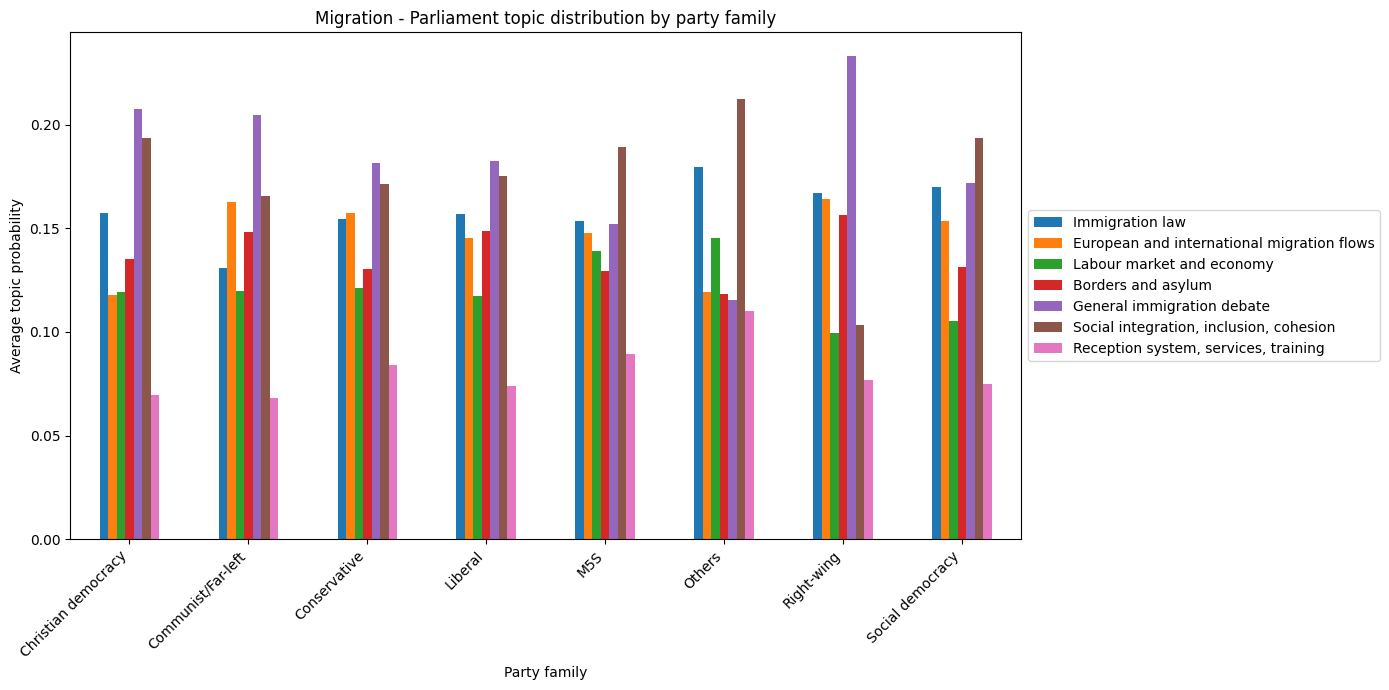

Saved party-family plot


In [ ]:
# plot for party families
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))

aggregate_by_party_docs_labeled = aggregate_by_party_docs.rename(columns=topic_labels)

aggregate_by_party_docs_labeled.plot.bar(ax=ax)

plt.title("Migration - Parliament topic distribution by party family")
plt.xlabel("Party family")
plt.ylabel("Average topic probability")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "topic_distribution_by_party_family.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved party-family plot")

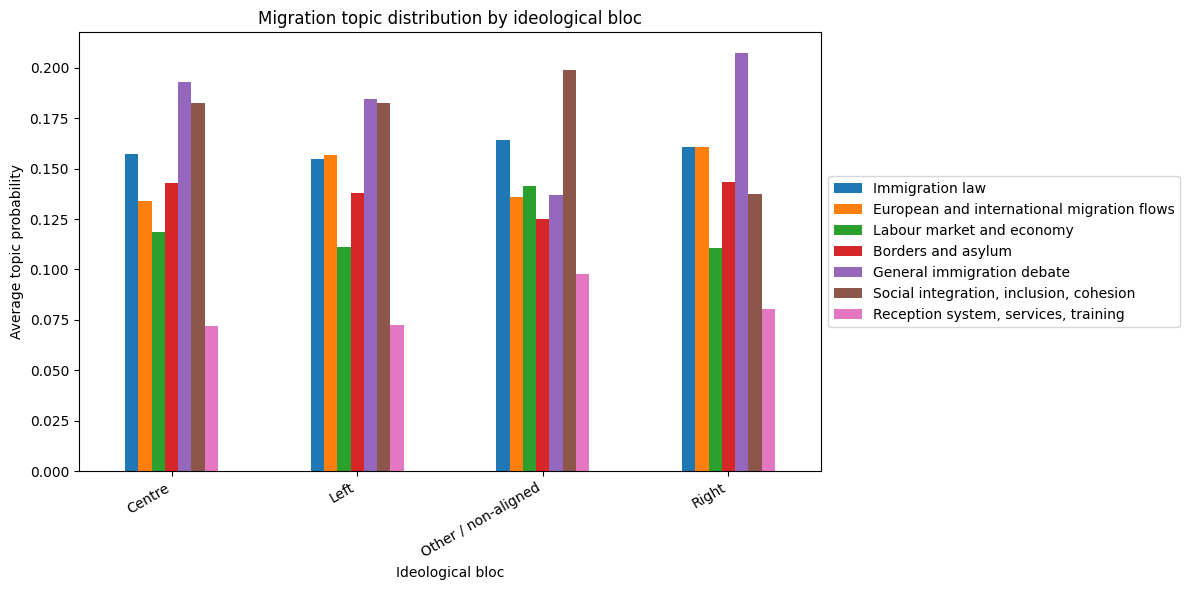

Saved ideological-bloc plot


In [ ]:
# plot for ideological blocs
fig, ax = plt.subplots(figsize=(12, 6))

aggregate_by_bloc_docs_labeled = aggregate_by_bloc_docs.rename(columns=topic_labels)

aggregate_by_bloc_docs_labeled.plot.bar(ax=ax)

plt.title("Migration topic distribution by ideological bloc")
plt.xlabel("Ideological bloc")
plt.ylabel("Average topic probability")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "topic_distribution_by_ideological_bloc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved ideological-bloc plot")

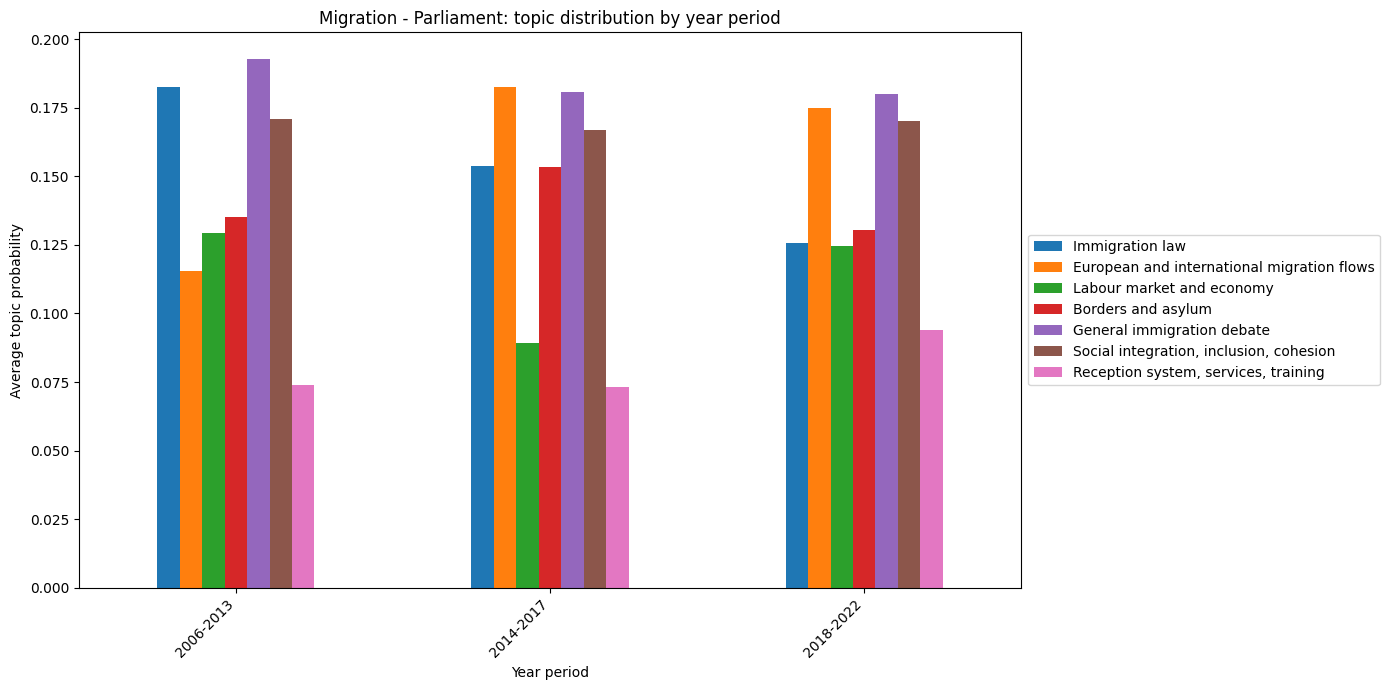

Saved year-period plot


In [ ]:
# Plot for year periods
fig, ax = plt.subplots(figsize=(14, 7))

aggregate_by_year_docs_labeled = aggregate_by_year_docs.rename(columns=topic_labels)

aggregate_by_year_docs_labeled.plot.bar(ax=ax)

plt.title("Migration - Parliament: topic distribution by year period")
plt.xlabel("Year period")
plt.ylabel("Average topic probability")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "topic_distribution_by_year_period.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved year-period plot")

### Manual validation of the model

In this section, we evaluate if the topics learned align with human interpretation. We evaluate the model by sampling 25 documents and manually annotate them. The annotators are asked to read the sentences and put a label corresponding to one of the topics. We then compute the match rate as a measure of human–model topic agreement. A Top-1 match indicates that the model's most probable topic corresponds to the human interpretation, while Top-2 and Top-3 matches allow for partial agreement when the document contains multiple themes or when the topic distribution is less concentrated.

In [ ]:
# Random sampling 25 sentences and create a table for annotation
manual_sample_25 = (
    topic_distros_docs
    .sample(n=25, random_state=42)
    .reset_index(drop=True)
)

annotation_blind_25 = manual_sample_25[
    ["speaker", "party_family", "year", "sentence"]
].copy()

annotation_blind_25.insert(0, "document_id", range(1, len(annotation_blind_25) + 1))

annotation_blind_25 = annotation_blind_25.rename(
    columns={"sentence": "document_text"}
)

annotation_blind_25["human_topic_label"] = ""

annotation_blind_25.head()

,document_id,speaker,party_family,year,document_text,human_topic_label
0,1,MARGHERITA BONIVER,Conservative,2009.0,"che riguarda il rafforzamento di frontex, il r...",
1,2,MATTEO MECACCI,Social democracy,2011.0,questo e un dato politico che credo segnali an...,
2,3,GUGLIELMO PICCHI,Conservative,2017.0,l'altra cosa e che dobbiamo rafforzare la nost...,
3,4,BRUNO MOLEA,Liberal,2013.0,"infatti, il circondario di cesena, che dovrebb...",
4,5,ERICA RIVOLTA,Right-wing,2012.0,le ricordo pero - e questo e un mio grandissim...,


In [ ]:
ANNOTATION_DIR_UN = Path("/content/drive/MyDrive/nlp_project/annotation")

annotation_blind_25.to_excel(
    ANNOTATION_DIR_UN / "lda_migration_manual_validation.xlsx",
    index=False
)

print("Saved annotation file to:")
print(ANNOTATION_DIR_UN / "lda_migration_manual_validation.xlsx")

Saved annotation file to:
/content/drive/MyDrive/nlp_project/lda_final_outputs_migration/lda_migration_manual_validation.xlsx


We load the annotated file to manually evaluate the model.

In [ ]:
# 1. Load annotated file
annotated_migration = pd.read_excel(
    ANNOTATION_DIR_UN / "ANNOTATED_ANNOTATED_lda_migration_manual_validation.xlsx"
)

annotated_migration = annotated_migration[["document_id", "human_topic_label"]].copy()
annotated_migration["human_topic_label"] = annotated_migration["human_topic_label"].astype(int)

# 2. Recreate the same 25 sampled documents
manual_sample_25 = (
    topic_distros_docs
    .sample(n=25, random_state=42)
    .reset_index(drop=True)
)

manual_sample_25.insert(
    0,
    "document_id",
    range(1, len(manual_sample_25) + 1)
)

In [ ]:
# 3. Identify topic probability columns
migration_topic_cols = [
    col for col in topic_distros_docs.columns
    if col.startswith("topic_")
]

# 4. Merge annotations with sampled documents and topic probabilities
validation_migration_clean = annotated_migration.merge(
    manual_sample_25[
        ["document_id", "speaker", "party_family", "year", "sentence"] + migration_topic_cols
    ],
    on="document_id",
    how="left"
)

In [ ]:
# 5. Compute top 1, top 2, top 3 model topics
topic_probs_migration = validation_migration_clean[migration_topic_cols]

validation_migration_clean["model_top1"] = (
    topic_probs_migration.idxmax(axis=1)
    .str.replace("topic_", "", regex=False)
    .astype(int)
)
validation_migration_clean["model_top1_prob"] = topic_probs_migration.max(axis=1)

validation_migration_clean["model_top2"] = topic_probs_migration.apply(
    lambda row: row.sort_values(ascending=False).index[1].replace("topic_", ""),
    axis=1
).astype(int)

validation_migration_clean["model_top2_prob"] = topic_probs_migration.apply(
    lambda row: row.sort_values(ascending=False).iloc[1],
    axis=1
)

validation_migration_clean["model_top3"] = topic_probs_migration.apply(
    lambda row: row.sort_values(ascending=False).index[2].replace("topic_", ""),
    axis=1
).astype(int)

validation_migration_clean["model_top3_prob"] = topic_probs_migration.apply(
    lambda row: row.sort_values(ascending=False).iloc[2],
    axis=1
)

To qualitatively validate the model, we compute the proportion of manually annotated documents where the human topic label is included among the model’s top-k most probable topics for k=1, 2, 3.

The interpretation of the match rates obtained is the following.


*   in 40% of the sampled documents the human-assigned topic corresponds to the model’s most probable topic
*   in 52% of documents, the human label appears among the model’s two most probable topics
*   in 64% of documents, the human label appears among the model’s three most probable topics.

This applies to all the other validation analysis in this notebook.


In [ ]:
# 6. Match indicators
validation_migration_clean["match_top1"] = (
    validation_migration_clean["human_topic_label"]
    == validation_migration_clean["model_top1"]
)

validation_migration_clean["match_top2"] = validation_migration_clean.apply(
    lambda row: row["human_topic_label"] in [row["model_top1"], row["model_top2"]],
    axis=1
)

validation_migration_clean["match_top3"] = validation_migration_clean.apply(
    lambda row: row["human_topic_label"] in [
        row["model_top1"],
        row["model_top2"],
        row["model_top3"]
    ],
    axis=1
)

# 7. Reorder columns
validation_migration_clean = validation_migration_clean[
    [
        "document_id",
        "speaker",
        "party_family",
        "year",
        "sentence",
        "human_topic_label",
        "model_top1",
        "model_top1_prob",
        "model_top2",
        "model_top2_prob",
        "model_top3",
        "model_top3_prob",
        "match_top1",
        "match_top2",
        "match_top3",
    ] + migration_topic_cols
]

# 8. Save the file
validation_migration_clean.to_excel(
    ANNOTATION_DIR_UN / "CHECKED_lda_migration_manual_validation.xlsx",
    index=False
)

print("Top-1 match rate:", validation_migration_clean["match_top1"].mean())
print("Top-2 match rate:", validation_migration_clean["match_top2"].mean())
print("Top-3 match rate:", validation_migration_clean["match_top3"].mean())

print("Saved checked file to:")
print(ANNOTATION_DIR_UN / "CHECKED_lda_migration_manual_validation.xlsx")

Top-1 match rate: 0.4
Top-2 match rate: 0.52
Top-3 match rate: 0.64
Saved checked file to:
/content/drive/MyDrive/nlp_project/annotation/CHECKED_lda_migration_manual_validation.xlsx


### Saving

The following cells are for saving the main outputs, models, graphs, etc...

This section will be replicated for all the analyses.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

OUTPUT_DIR = Path("/content/drive/MyDrive/nlp_project/lda_final_outputs_migration")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", OUTPUT_DIR)

Saving outputs to: /content/drive/MyDrive/nlp_project/lda_final_outputs_migration


In [ ]:
# Save final aggregated/preprocessed speech-level dataset

df_docs_migration.to_csv(
    OUTPUT_DIR / "df_docs_migration_aggregated.csv",
    index=False
)

df_docs_migration.to_pickle(
    OUTPUT_DIR / "df_docs_migration_aggregated.pkl"
)

print("Saved df_docs_migration")

Saved df_docs_migration


In [ ]:
import pickle
# Save tokenized/bigram documents used for LDA
with open(OUTPUT_DIR / "instances_bigram_docs.pkl", "wb") as f:
    pickle.dump(instances_bigram_docs, f)

print("Saved instances_bigram_docs")

Saved instances_bigram_docs


In [ ]:
# Save Gensim dictionary
dictionary_docs.save(str(OUTPUT_DIR / "dictionary_docs.gensim"))

# Save LDA corpus
with open(OUTPUT_DIR / "ldacorpus_docs.pkl", "wb") as f:
    pickle.dump(ldacorpus_docs, f)

print("Saved dictionary_docs and ldacorpus_docs")

Saved dictionary_docs and ldacorpus_docs


In [ ]:
# Save final model
final_model_docs.save(str(OUTPUT_DIR / "final_lda_model_docs_K7.model"))

print("Saved final model to:", OUTPUT_DIR / "final_lda_model_docs_K7.model")

Saved final model to: /content/drive/MyDrive/nlp_project/lda_final_outputs_migration/final_lda_model_docs_K7.model


In [ ]:
# Save document-level topic distributions

topic_distros_docs.to_csv(
    OUTPUT_DIR / "topic_distributions_docs.csv",
    index=False
)

topic_distros_docs.to_pickle(
    OUTPUT_DIR / "topic_distributions_docs.pkl"
)

print("Saved topic_distros_docs")

Saved topic_distros_docs


In [ ]:
# Save coherence results

coherence_df_docs.to_csv(
    OUTPUT_DIR / "coherence_results_docs.csv",
    index=False
)

with open(OUTPUT_DIR / "coherence_values_docs.pkl", "wb") as f:
    pickle.dump(coherence_values_docs, f)

print("Saved coherence results")

Saved coherence results


In [ ]:
# Final topic labels

topic_labels = {
    "topic_0": "Immigration law",
    "topic_1": "European and international migration flows",
    "topic_2": "Labour market and economy",
    "topic_3": "Borders and asylum",
    "topic_4": "General immigration debate",
    "topic_5": "Social integration, inclusion, cohesion",
    "topic_6": "Reception system, services, training"
}

pd.Series(topic_labels).to_csv(
    OUTPUT_DIR / "topic_labels.csv",
    header=["label"]
)

with open(OUTPUT_DIR / "topic_labels.pkl", "wb") as f:
    pickle.dump(topic_labels, f)

print("Saved topic labels")

Saved topic labels


In [ ]:
# Save aggregate topic-distribution tables

aggregate_by_party_docs.to_csv(
    OUTPUT_DIR / "aggregate_topic_distribution_by_party_family.csv"
)

print("Saved party-family aggregate table")

aggregate_by_year_docs.to_csv(
    OUTPUT_DIR / "aggregate_topic_distribution_by_year_period.csv"
)

print("Saved year-period aggregate table")

aggregate_by_bloc_docs.to_csv(
    OUTPUT_DIR / "aggregate_topic_distribution_by_ideological_bloc.csv"
)

print("Saved ideological-bloc aggregate table")

Saved party-family aggregate table
Saved year-period aggregate table
Saved ideological-bloc aggregate table


In [ ]:
saved_files = sorted([p.name for p in OUTPUT_DIR.iterdir()])

print("Saved files:")
for file in saved_files:
    print("-", file)

Saved files:
- aggregate_topic_distribution_by_ideological_bloc.csv
- aggregate_topic_distribution_by_party_family.csv
- aggregate_topic_distribution_by_year_period.csv
- coherence_results_docs.csv
- coherence_values_docs.pkl
- df_docs_migration_aggregated.csv
- df_docs_migration_aggregated.pkl
- dictionary_docs.gensim
- final_lda_model_docs_K7.model
- final_lda_model_docs_K7.model.expElogbeta.npy
- final_lda_model_docs_K7.model.id2word
- final_lda_model_docs_K7.model.state
- instances_bigram_docs.pkl
- ldacorpus_docs.pkl
- topic_distribution_by_ideological_bloc.png
- topic_distribution_by_party_family.png
- topic_distribution_by_year_period.png
- topic_distributions_docs.csv
- topic_distributions_docs.pkl
- topic_labels.csv
- topic_labels.pkl


### Reloading

These cells are for reloading the saved outputs and final model.

Similar code is used later for reloading sections of the other three analyses.

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

matches = list(Path("/content/drive").rglob("df_docs_migration_aggregated.pkl"))

print("Matches found:")
for m in matches:
    print(m)

OUTPUT_DIR = matches[0].parent
print("Using OUTPUT_DIR:", OUTPUT_DIR)

Mounted at /content/drive
Matches found:
/content/drive/MyDrive/nlp_project/lda_final_outputs_migration/df_docs_migration_aggregated.pkl
Using OUTPUT_DIR: /content/drive/MyDrive/nlp_project/lda_final_outputs_migration


In [ ]:
import pickle
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaModel

df_docs_migration = pd.read_pickle(
    OUTPUT_DIR / "df_docs_migration_aggregated.pkl"
)

topic_distros_docs = pd.read_pickle(
    OUTPUT_DIR / "topic_distributions_docs.pkl"
)

with open(OUTPUT_DIR / "instances_bigram_docs.pkl", "rb") as f:
    instances_bigram_docs = pickle.load(f)

dictionary_docs = Dictionary.load(
    str(OUTPUT_DIR / "dictionary_docs.gensim")
)

with open(OUTPUT_DIR / "ldacorpus_docs.pkl", "rb") as f:
    ldacorpus_docs = pickle.load(f)

final_model_docs = LdaModel.load(
    str(OUTPUT_DIR / "final_lda_model_docs_K7.model")
)

coherence_df_docs = pd.read_csv(
    OUTPUT_DIR / "coherence_results_docs.csv"
)

topic_labels = pd.read_csv(
    OUTPUT_DIR / "topic_labels.csv",
    index_col=0
)["label"].to_dict()

print("Reloaded final LDA project outputs")

Reloaded final LDA project outputs


## UN speeches

Here starts the analysis for the UN speeches about migration. It follows the same structure of the previous LDA topic modeling section, with minor differences, pointed out in the comments when necessary.

In [ ]:
# Loading the data
folder_url = "https://drive.google.com/drive/folders/1cL0iFYg12tJR8wPdJ6ceZL_RMAoyg9sx"

# Download folder into a known directory
out_dir = "un_migration_data"
gdown.download_folder(folder_url, output=out_dir, quiet=False, use_cookies=False)

# Check what was actually downloaded
for root, dirs, files in os.walk(out_dir):
    for f in files:
        print(os.path.join(root, f))

# Find pickle files
matches = glob.glob(f"{out_dir}/**/*.pkl", recursive=True)
print("Pickle files found:", matches)

# Then load the right one
pkl_path = [m for m in matches if "df_f1_m_un" in os.path.basename(m)]

if len(pkl_path) == 0:
    raise FileNotFoundError("df_f1_m_un.pkl was not found. Check the printed file names above.")

df_un_migration = pd.read_pickle(pkl_path[0])
df_un_migration.head()

Retrieving folder contents


Processing file 1WMm7F0_IHbdOEZfF7q46OZmZK1tjkrBZ df_f1_m_un.pkl
Processing file 1hK1fzXx7K8hnOicaaNrTc5rFGIAPQRZ- df_f1_m.pkl
Processing file 1zsuCK44oroQXLEQygA6F2XUAVFWvbQC1 df_f2_m.pkl
Processing file 1MkuLjyyg9cyxQHWHu0nP6PkM05SpPZyQ df_final_m_year.pkl
Processing file 1QXcxD1xqfMjNawn8ymmMYzlhqINoQNYv df_final_m.pkl
Processing file 1WhVZRtKrAaSFVyuk7IFo8snuuxhtpg2f df_m_full.pkl
Processing file 18zu_gxhiPqkfw2GKAa9EMjVymHVpPGaw df_m_L.pkl
Processing file 1otH8o_4jbSt8_A4O2jUtVDWaqlJrMoYI df_m_presidente.pkl
Processing file 1FZ-KYV1dJRcNNunnwf87pGVXZDdCJhUC df_m_R.pkl
Processing file 1UtbsmcB4Tx5nJfuccJF-_4zDRzz0jDLy df_m_year_g.pkl
Processing file 1a_3eDQMpC1KiNivGvcfkbsshYVHxHmw5 df_semantic_m.pkl
Processing file 1SsVrl-dr3PhjyXy2jm8Vx0gdDWeY81EK df_sent.pkl
Processing file 1j_128_RqIuXGmFV42DdRljU0Ki1JsfHR top_speeches_m.pkl


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1WMm7F0_IHbdOEZfF7q46OZmZK1tjkrBZ
To: /content/un_migration_data/df_f1_m_un.pkl
100%|██████████| 349k/349k [00:00<00:00, 102MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hK1fzXx7K8hnOicaaNrTc5rFGIAPQRZ-
To: /content/un_migration_data/df_f1_m.pkl
100%|██████████| 9.58M/9.58M [00:00<00:00, 249MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zsuCK44oroQXLEQygA6F2XUAVFWvbQC1
To: /content/un_migration_data/df_f2_m.pkl
100%|██████████| 5.73M/5.73M [00:00<00:00, 25.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MkuLjyyg9cyxQHWHu0nP6PkM05SpPZyQ
To: /content/un_migration_data/df_final_m_year.pkl
100%|██████████| 32.2M/32.2M [00:00<00:00, 72.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QXcxD1xqfMjNawn8ymmMYzlhqINoQNYv
To: /content/un_migration_data/df_final_m.pkl
100%|██████████| 32.1M/32.1M

un_migration_data/df_m_R.pkl
un_migration_data/df_m_presidente.pkl
un_migration_data/df_f1_m_un.pkl
un_migration_data/df_final_m_year.pkl
un_migration_data/df_f1_m.pkl
un_migration_data/df_sent.pkl
un_migration_data/df_m_L.pkl
un_migration_data/df_final_m.pkl
un_migration_data/top_speeches_m.pkl
un_migration_data/df_m_year_g.pkl
un_migration_data/df_m_full.pkl
un_migration_data/df_semantic_m.pkl
un_migration_data/df_f2_m.pkl
Pickle files found: ['un_migration_data/df_m_R.pkl', 'un_migration_data/df_m_presidente.pkl', 'un_migration_data/df_f1_m_un.pkl', 'un_migration_data/df_final_m_year.pkl', 'un_migration_data/df_f1_m.pkl', 'un_migration_data/df_sent.pkl', 'un_migration_data/df_m_L.pkl', 'un_migration_data/df_final_m.pkl', 'un_migration_data/top_speeches_m.pkl', 'un_migration_data/df_m_year_g.pkl', 'un_migration_data/df_m_full.pkl', 'un_migration_data/df_semantic_m.pkl', 'un_migration_data/df_f2_m.pkl']



Download completed


,row_id,DATE,TEXT,text_clean,sentence,sentence_id,keyword_hits,n_keyword_hits
0,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...","it is that gap, above all, that causes the mas...",69,[migratory flows],1
1,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",in the mediterranean we are working with our p...,70,"[immigration, integration]",2
2,5,2011,Italy has a long tradition of \nmediation that...,italy has a long tradition of mediation that h...,"11-51378 10 on the face of it, the approach fa...",9,[migration],1
3,6,2012,"﻿I wish to warmly congratulate\nyou, Mr. Presi...","﻿i wish to warmly congratulate you, mr. presid...",we cannot overlook the importance of the measu...,13,[integration],1
4,6,2012,"﻿I wish to warmly congratulate\nyou, Mr. Presi...","﻿i wish to warmly congratulate you, mr. presid...",it will have to include such important dimensi...,77,[migration],1


Naturally, we use Spacy for English as the speeches in the UN datasets are all in English. We consider again some stopwords, similar to the ones included in the Italian case.

In [ ]:
# 2. Preprocessing (we skip aggregating over speeches for limited data numerosity)
nlp_en = spacy.load("en_core_web_sm")

custom_stopwords_un = {
    # UN / speech setting
    "united", "nations", "assembly",
    "president", "secretary", "general",
    "session", "meeting",
    "statement", "speech",

    # generic courtesy / procedural words
    "thank", "thanks",
    "today",
    "year"
}

def preprocess_english_text_un(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)

    doc = nlp_en(text)
    tokens = []

    for token in doc:
        lemma = token.lemma_.lower().strip()

        if token.is_stop:
            continue
        if token.is_punct or token.is_space:
            continue
        if token.like_num:
            continue
        if not token.is_alpha:
            continue
        if len(lemma) <= 2:
            continue
        if lemma in custom_stopwords_un:
            continue

        tokens.append(lemma)

    return tokens

df_un_migration["tokens"] = df_un_migration["sentence"].apply(preprocess_english_text_un)
df_un_migration["cleaned_text"] = df_un_migration["tokens"].apply(lambda x: " ".join(x))

df_un_migration = df_un_migration[df_un_migration["tokens"].map(len) > 0].copy()

df_un_migration.head()

,row_id,DATE,TEXT,text_clean,sentence,sentence_id,keyword_hits,n_keyword_hits,tokens,cleaned_text
0,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...","it is that gap, above all, that causes the mas...",69,[migratory flows],1,"[gap, cause, massive, migratory, flow, ignore,...",gap cause massive migratory flow ignore addres...
1,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",in the mediterranean we are working with our p...,70,"[immigration, integration]",2,"[mediterranean, work, partner, address, immigr...",mediterranean work partner address immigration...
2,5,2011,Italy has a long tradition of \nmediation that...,italy has a long tradition of mediation that h...,"11-51378 10 on the face of it, the approach fa...",9,[migration],1,"[face, approach, favour, european, western, co...",face approach favour european western country ...
3,6,2012,"﻿I wish to warmly congratulate\nyou, Mr. Presi...","﻿i wish to warmly congratulate you, mr. presid...",we cannot overlook the importance of the measu...,13,[integration],1,"[overlook, importance, measure, take, level, s...",overlook importance measure take level strengt...
4,6,2012,"﻿I wish to warmly congratulate\nyou, Mr. Presi...","﻿i wish to warmly congratulate you, mr. presid...",it will have to include such important dimensi...,77,[migration],1,"[include, important, dimension, development, r...",include important dimension development reduce...


In [ ]:
# 3. Add bigrams
instances_un = df_un_migration["tokens"].tolist()

bigram_un = Phrases(
    instances_un,
    min_count=2,      # lower because dataset is small
    threshold=5       # lower = more bigrams
)

bigram_mod_un = Phraser(bigram_un)

instances_bigram_un = [bigram_mod_un[doc] for doc in instances_un]

df_un_migration["tokens_bigram"] = instances_bigram_un
df_un_migration["cleaned_text_bigram"] = df_un_migration["tokens_bigram"].apply(lambda x: " ".join(x))

df_un_migration[["sentence", "tokens_bigram"]].head()

,sentence,tokens_bigram
0,"it is that gap, above all, that causes the mas...","[gap, cause, massive, migratory_flow, ignore, ..."
1,in the mediterranean we are working with our p...,"[mediterranean, work, partner, address, immigr..."
2,"11-51378 10 on the face of it, the approach fa...","[face, approach, favour, european, western, co..."
3,we cannot overlook the importance of the measu...,"[overlook, importance, measure, take, level, s..."
4,it will have to include such important dimensi...,"[include, important, dimension, development, r..."


In creating the dictionary, we use different thresholds to exclude too rare/too common tokens, considering that this dataset is quite small, compared to the Italian one.

In [ ]:
# 4. Create dictionary and corpus for UN migration speeches
dictionary_un = Dictionary(instances_bigram_un)

dictionary_un.filter_extremes(
    no_below=1,
    no_above=0.6
)

ldacorpus_un = [dictionary_un.doc2bow(text) for text in instances_bigram_un]

print(dictionary_un)

Dictionary<481 unique tokens: ['address', 'cause', 'equanimity', 'especially', 'gap']...>


We explore different values of K (i.e. number of topics), and we choose the one with the highest coherence score.

In [ ]:
# 5. Try K = 2, 3, 4, 5 and compare c_v coherence
coherence_values_un = []
models_un = {}

for num_topics_un in [2, 3, 4, 5]:
    print(f"\nK = {num_topics_un}")

    temp_model_un = LdaMulticore(
        corpus=ldacorpus_un,
        id2word=dictionary_un,
        num_topics=num_topics_un,
        passes=20,
        workers=2,
        random_state=42
    )

    coherence_model_un = CoherenceModel(
        model=temp_model_un,
        texts=instances_bigram_un,
        dictionary=dictionary_un,
        coherence="c_v"
    )

    cv_score_un = coherence_model_un.get_coherence()

    coherence_values_un.append((num_topics_un, cv_score_un))
    models_un[num_topics_un] = temp_model_un

    print("c_v:", cv_score_un)

    for topic_id, topic_words in temp_model_un.print_topics(
        num_topics=num_topics_un,
        num_words=12
    ):
        print(f"Topic {topic_id}: {topic_words}")

# Summary table
coherence_df_un = pd.DataFrame(
    coherence_values_un,
    columns=["K", "c_v"]
).sort_values("c_v", ascending=False)

coherence_df_un


K = 2
c_v: 0.3998304117891396
Topic 0: 0.023*"migration" + 0.018*"refugee" + 0.013*"level" + 0.012*"italy" + 0.010*"migrant" + 0.009*"global" + 0.009*"phenomenon" + 0.008*"international" + 0.007*"address" + 0.007*"question" + 0.007*"organization" + 0.006*"immigrant"
Topic 1: 0.017*"migration" + 0.010*"country" + 0.010*"life" + 0.010*"mediterranean" + 0.009*"challenge" + 0.009*"migrant" + 0.008*"thousand" + 0.008*"human" + 0.008*"italy" + 0.007*"flow" + 0.007*"italian" + 0.007*"european"

K = 3
c_v: 0.41190645072384263
Topic 0: 0.015*"refugee" + 0.015*"italy" + 0.013*"level" + 0.013*"global" + 0.013*"phenomenon" + 0.012*"migration" + 0.010*"address" + 0.010*"migrant" + 0.010*"question" + 0.008*"immigrant" + 0.008*"risk" + 0.008*"time"
Topic 1: 0.020*"migration" + 0.014*"life" + 0.012*"italy" + 0.010*"thousand" + 0.010*"human" + 0.009*"challenge" + 0.009*"mediterranean" + 0.009*"fight" + 0.007*"italian" + 0.007*"woman" + 0.007*"save" + 0.007*"coast_guard"
Topic 2: 0.027*"migration" + 0.

,K,c_v
2,4,0.420446
1,3,0.411906
0,2,0.399830
3,5,0.391509


We train the final model and compute diversity score to evaluate topic quality.

In [ ]:
# 6. Train final model for UN migration speeches
num_topics_un = 4  # chosen after inspecting coherence and interpretability

final_model_un = LdaModel(
    corpus=ldacorpus_un,
    id2word=dictionary_un,
    num_topics=num_topics_un,
    passes=20,
    random_state=42
)

for topic_id, topic_words in final_model_un.print_topics(
    num_topics=num_topics_un,
    num_words=15
):
    print(f"Topic {topic_id}: {topic_words}")

Topic 0: 0.022*"migration" + 0.015*"level" + 0.015*"international" + 0.012*"need" + 0.012*"risk" + 0.008*"ukraine" + 0.008*"time" + 0.008*"question" + 0.008*"great" + 0.008*"integration" + 0.008*"action" + 0.008*"italy" + 0.008*"high" + 0.008*"european" + 0.008*"phenomenon"
Topic 1: 0.020*"migration" + 0.013*"life" + 0.013*"challenge" + 0.010*"human" + 0.010*"fight" + 0.007*"trafficker" + 0.007*"country" + 0.007*"face" + 0.007*"political" + 0.007*"flow" + 0.007*"mediterranean" + 0.007*"counter" + 0.007*"community" + 0.007*"share" + 0.007*"dignity"
Topic 2: 0.018*"refugee" + 0.016*"migration" + 0.016*"work" + 0.013*"country" + 0.010*"crisis" + 0.010*"italy" + 0.007*"migrant" + 0.007*"development" + 0.007*"support" + 0.007*"address" + 0.007*"humanitarian" + 0.007*"facilitate" + 0.007*"governance" + 0.007*"flow" + 0.007*"mediterranean"
Topic 3: 0.021*"migration" + 0.019*"migrant" + 0.016*"italy" + 0.014*"thousand" + 0.014*"immigrant" + 0.011*"address" + 0.009*"refugee" + 0.009*"global" + 

In [ ]:
# 7. Topic Diversity for final UN LDA model

# Number of top words considered per topic
num_words = 12

# Extract top words for each topic
topic_words_un = [
    [word for word, prob in final_model_un.show_topic(topic_id, topn=num_words)]
    for topic_id in range(num_topics_un)
]

# Collect unique words across all topics
unique_words_un = set()

for topic in topic_words_un:
    unique_words_un.update(topic[:num_words])

# Topic Diversity:
# ratio of unique words to total number of words across all topics
td_un = len(unique_words_un) / (num_words * len(topic_words_un))

print(
    f"Topic Diversity (top-{num_words} words): {td_un:.4f} "
    f"[unique words = {len(unique_words_un)}, "
    f"total words = {num_words * len(topic_words_un)}]"
)

Topic Diversity (top-12 words): 0.8125 [unique words = 39, total words = 48]


In [ ]:
# 8. Get topic distribution for each UN speech/document and attach metadata
topic_corpus_un = final_model_un.get_document_topics(
    ldacorpus_un,
    minimum_probability=0
)

descriptors_un = [f"topic_{i}" for i in range(num_topics_un)]

scores_un = [
    [topic_prob for topic_id, topic_prob in doc_topics]
    for doc_topics in topic_corpus_un
]

topic_distros_un = pd.DataFrame(
    data=scores_un,
    columns=descriptors_un
)

# attach metadata columns only if they exist
metadata_cols = ["country", "year", "date", "speaker", "sentence"]

for col in metadata_cols:
    if col in df_un_migration.columns:
        topic_distros_un[col] = df_un_migration[col].values

topic_distros_un.head()

,topic_0,topic_1,topic_2,topic_3,sentence
0,0.020960,0.021056,0.021367,0.936617,"it is that gap, above all, that causes the mas..."
1,0.009363,0.009463,0.971770,0.009403,in the mediterranean we are working with our p...
2,0.012143,0.963562,0.012329,0.011966,"11-51378 10 on the face of it, the approach fa..."
3,0.020038,0.019404,0.019638,0.940921,we cannot overlook the importance of the measu...
4,0.010975,0.011009,0.966973,0.011043,it will have to include such important dimensi...


In this case, we group only by year periods, as naturally there is no party or ideological splitting at UN assemblies.

In [ ]:
# 10. group by year period
topic_distros_un["DATE"] = df_un_migration["DATE"].values

# DATE is actually a year, not a full date
topic_distros_un["year"] = pd.to_numeric(
    topic_distros_un["DATE"],
    errors="coerce"
).astype("Int64")

# Combine 2006-2009 and 2010-2013 into one period
topic_distros_un["year_period"] = pd.cut(
    topic_distros_un["year"],
    bins=[2005, 2013, 2017, 2022],
    labels=["2006-2013", "2014-2017", "2018-2022"],
    include_lowest=True
)

topic_distros_un[["DATE", "year", "year_period"]].head()

,DATE,year,year_period
0,2006,2006,2006-2013
1,2006,2006,2006-2013
2,2011,2011,2006-2013
3,2012,2012,2006-2013
4,2012,2012,2006-2013


In [ ]:
# Create aggregate topic-distribution table by year period for UN migration speeches

aggregate_by_year_period_un = (
    topic_distros_un
    .dropna(subset=["year_period"])
    .groupby("year_period")[descriptors_un]
    .mean()
)

aggregate_by_year_period_un

/tmp/ipykernel_2614/2999808783.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("year_period")[descriptors_un]


,topic_0,topic_1,topic_2,topic_3
year_period,,,,
2006-2013,0.089922,0.152616,0.220643,0.536820
2014-2017,0.264035,0.269222,0.172197,0.294546
2018-2022,0.176159,0.215034,0.291983,0.316824


In [ ]:
# Topic labels for UN migration LDA model
topic_labels_un = {
    "topic_0": "International migration and integration",
    "topic_1": "Humanitarian challenges",
    "topic_2": "Refugee crisis and support",
    "topic_3": "Italy and migrants"
}

In [ ]:
# directory to save plots
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

OUTPUT_DIR_UN = Path("/content/drive/MyDrive/nlp_project/lda_final_outputs_un_migration")
OUTPUT_DIR_UN.mkdir(parents=True, exist_ok=True)

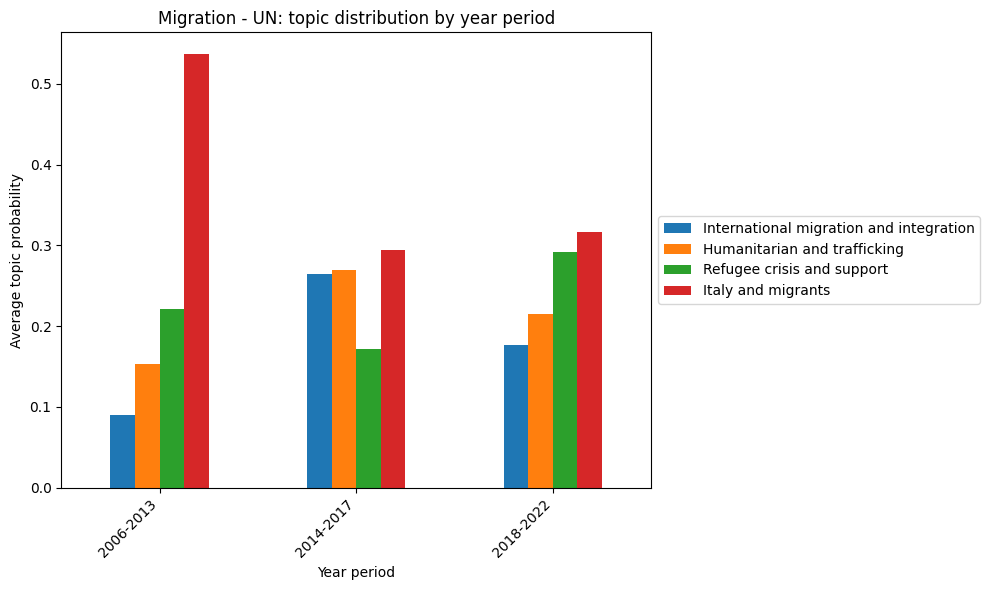

Saved UN migration year-period plot


In [ ]:
# 11. Plot topic distribution by year period
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

aggregate_by_year_period_un_labeled = aggregate_by_year_period_un.rename(
    columns=topic_labels_un
)

aggregate_by_year_period_un_labeled.plot.bar(ax=ax)

plt.title("Migration - UN: topic distribution by year period")
plt.xlabel("Year period")
plt.ylabel("Average topic probability")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR_UN / "topic_distribution_by_year_period_un_migration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved UN migration year-period plot")

### Manual validation of the model

In this section, similarly to what already presented with the Italian parliamentary dataset on migration, we qualitatively evaluate the model exploting human annotation and using the same match rate metric.

In [ ]:
ANNOTATION_DIR_UN = Path("/content/drive/MyDrive/nlp_project/annotation")
ANNOTATION_DIR_UN.mkdir(parents=True, exist_ok=True)

print("Saving annotation files to:", ANNOTATION_DIR_UN)

Saving annotation files to: /content/drive/MyDrive/nlp_project/annotation


In [ ]:
# Randomly sample 25 UN sentences/documents for manual validation

manual_sample_25_un = (
    topic_distros_un
    .sample(n=25, random_state=42)
    .reset_index(drop=True)
)

# Select available metadata columns
candidate_cols_un = ["country", "speaker", "DATE", "year", "year_period", "sentence"]
available_cols_un = [col for col in candidate_cols_un if col in manual_sample_25_un.columns]

annotation_blind_25_un = manual_sample_25_un[
    available_cols_un
].copy()

# Add document ID
annotation_blind_25_un.insert(
    0,
    "document_id",
    range(1, len(annotation_blind_25_un) + 1)
)

# Rename sentence column for annotation
annotation_blind_25_un = annotation_blind_25_un.rename(
    columns={"sentence": "document_text"}
)

# Add empty human annotation column
annotation_blind_25_un["human_topic_label"] = ""

annotation_blind_25_un.head()

,document_id,DATE,year,year_period,document_text,human_topic_label
0,1,2020,2020,2018-2022,we thus need collective action against the net...,
1,2,2021,2021,2018-2022,"in particular, i am referring to the internati...",
2,3,2006,2006,2006-2013,"it is that gap, above all, that causes the mas...",
3,4,2019,2019,2018-2022,it is a path strengthened by measures for soci...,
4,5,2012,2012,2006-2013,migrant remittances play a key role in the dev...,


In [ ]:
annotation_blind_25_un.to_excel(
    ANNOTATION_DIR_UN / "lda_un_migration_manual_validation.xlsx",
    index=False
)

print("Saved UN annotation file to:")
print(ANNOTATION_DIR_UN / "lda_un_migration_manual_validation.xlsx")

Saved UN annotation file to:
/content/drive/MyDrive/nlp_project/annotation/lda_un_migration_manual_validation.xlsx


In [ ]:
# 1. Reload annotated file
annotated_un = pd.read_excel(
    ANNOTATION_DIR_UN / "ANNOTATED_lda_un_migration_manual_validation.xlsx"
)

annotated_un = annotated_un[["document_id", "human_topic_label"]].copy()
annotated_un["human_topic_label"] = annotated_un["human_topic_label"].astype(int)

# 2. Recreate same 25 sampled documents
manual_sample_25_un = (
    topic_distros_un
    .sample(n=25, random_state=42)
    .reset_index(drop=True)
)

manual_sample_25_un.insert(
    0,
    "document_id",
    range(1, len(manual_sample_25_un) + 1)
)

In [ ]:
# 3. Identify topic probability columns
un_topic_cols = [f"topic_{i}" for i in range(4)]

# 4. Merge annotations with sampled docs + topic probabilities
metadata_cols_un = [
    col for col in ["country", "speaker", "DATE", "year", "year_period", "sentence"]
    if col in manual_sample_25_un.columns
]

validation_un_clean = annotated_un.merge(
    manual_sample_25_un[
        ["document_id"] + metadata_cols_un + un_topic_cols
    ],
    on="document_id",
    how="left"
)

In [ ]:
# 5. Compute top 1, top 2, top 3 model topics
topic_probs_un = validation_un_clean[un_topic_cols]

validation_un_clean["model_top1"] = topic_probs_un.idxmax(axis=1).str.replace("topic_", "").astype(int)
validation_un_clean["model_top1_prob"] = topic_probs_un.max(axis=1)

validation_un_clean["model_top2"] = topic_probs_un.apply(
    lambda row: row.sort_values(ascending=False).index[1].replace("topic_", ""),
    axis=1
).astype(int)

validation_un_clean["model_top2_prob"] = topic_probs_un.apply(
    lambda row: row.sort_values(ascending=False).iloc[1],
    axis=1
)

validation_un_clean["model_top3"] = topic_probs_un.apply(
    lambda row: row.sort_values(ascending=False).index[2].replace("topic_", ""),
    axis=1
).astype(int)

validation_un_clean["model_top3_prob"] = topic_probs_un.apply(
    lambda row: row.sort_values(ascending=False).iloc[2],
    axis=1
)

We obtain the match rates and observe that, considering the task of topic modeling, already in 44% of the documents the human topic label matches the model most probable topic. This percentace increase up to 88% when we consider the three most probable topics.

In [ ]:
# 6. Match indicators
validation_un_clean["match_top1"] = (
    validation_un_clean["human_topic_label"] == validation_un_clean["model_top1"]
)

validation_un_clean["match_top2"] = validation_un_clean.apply(
    lambda row: row["human_topic_label"] in [row["model_top1"], row["model_top2"]],
    axis=1
)

validation_un_clean["match_top3"] = validation_un_clean.apply(
    lambda row: row["human_topic_label"] in [row["model_top1"], row["model_top2"], row["model_top3"]],
    axis=1
)

# 8. Reorder columns
validation_un_clean = validation_un_clean[
    ["document_id"]
    + metadata_cols_un
    + [
        "human_topic_label",
        "model_top1",
        "model_top1_prob",
        "model_top2",
        "model_top2_prob",
        "model_top3",
        "model_top3_prob",
        "match_top1",
        "match_top2",
        "match_top3",
    ]
    + un_topic_cols
]

# 9. Save clean checked file
validation_un_clean.to_excel(
    ANNOTATION_DIR_UN / "CHECKED_lda_un_migration_manual_validation.xlsx",
    index=False
)

print("Top-1 match rate:", validation_un_clean["match_top1"].mean())
print("Top-2 match rate:", validation_un_clean["match_top2"].mean())
print("Top-3 match rate:", validation_un_clean["match_top3"].mean())

print("Saved checked file to:")
print(ANNOTATION_DIR_UN / "CHECKED_lda_un_migration_manual_validation.xlsx")

validation_un_clean.head()

Top-1 match rate: 0.44
Top-2 match rate: 0.64
Top-3 match rate: 0.88
Saved checked file to:
/content/drive/MyDrive/nlp_project/annotation/CHECKED_lda_un_migration_manual_validation.xlsx


,document_id,DATE,year,year_period,sentence,human_topic_label,model_top1,model_top1_prob,model_top2,model_top2_prob,model_top3,model_top3_prob,match_top1,match_top2,match_top3,topic_0,topic_1,topic_2,topic_3
0,1,2020,2020,2018-2022,we thus need collective action against the net...,1,2,0.902328,1,0.033935,0,0.032218,False,True,True,0.032218,0.033935,0.902328,0.031518
1,2,2021,2021,2018-2022,"in particular, i am referring to the internati...",0,0,0.914045,2,0.029090,3,0.028586,True,True,True,0.914045,0.028279,0.029090,0.028586
2,3,2006,2006,2006-2013,"it is that gap, above all, that causes the mas...",3,3,0.936617,2,0.021367,1,0.021056,True,True,True,0.020960,0.021056,0.021367,0.936617
3,4,2019,2019,2018-2022,it is a path strengthened by measures for soci...,2,0,0.941672,3,0.019565,1,0.019514,False,False,False,0.941672,0.019514,0.019249,0.019565
4,5,2012,2012,2006-2013,migrant remittances play a key role in the dev...,3,3,0.899677,2,0.034885,1,0.033714,True,True,True,0.031724,0.033714,0.034885,0.899677


### Saving

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

OUTPUT_DIR_UN = Path("/content/drive/MyDrive/nlp_project/lda_final_outputs_un_migration")
OUTPUT_DIR_UN.mkdir(parents=True, exist_ok=True)

print("Saving UN outputs to:", OUTPUT_DIR_UN)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving UN outputs to: /content/drive/MyDrive/nlp_project/lda_final_outputs_un_migration


In [ ]:
df_un_migration.to_csv(
    OUTPUT_DIR_UN / "df_un_migration_processed.csv",
    index=False
)

df_un_migration.to_pickle(
    OUTPUT_DIR_UN / "df_un_migration_processed.pkl"
)

print("Saved df_un_migration")

Saved df_un_migration


In [ ]:
import pickle

with open(OUTPUT_DIR_UN / "instances_bigram_un.pkl", "wb") as f:
    pickle.dump(instances_bigram_un, f)

print("Saved instances_bigram_un")

Saved instances_bigram_un


In [ ]:
dictionary_un.save(
    str(OUTPUT_DIR_UN / "dictionary_un.gensim")
)

with open(OUTPUT_DIR_UN / "ldacorpus_un.pkl", "wb") as f:
    pickle.dump(ldacorpus_un, f)

print("Saved dictionary_un and ldacorpus_un")

Saved dictionary_un and ldacorpus_un


In [ ]:
final_model_un.save(
    str(OUTPUT_DIR_UN / "final_lda_model_un_K4.model")
)

print("Saved final UN model to:", OUTPUT_DIR_UN / "final_lda_model_un_K4.model")

Saved final UN model to: /content/drive/MyDrive/nlp_project/lda_final_outputs_un_migration/final_lda_model_un_K4.model


In [ ]:
topic_distros_un.to_csv(
    OUTPUT_DIR_UN / "topic_distributions_un.csv",
    index=False
)

topic_distros_un.to_pickle(
    OUTPUT_DIR_UN / "topic_distributions_un.pkl"
)

print("Saved topic_distros_un")

Saved topic_distros_un


In [ ]:
# Save topic words
with open(OUTPUT_DIR_UN / "topic_words_un.pkl", "wb") as f:
    pickle.dump(topic_words_un, f)

# Save topic diversity as a small CSV
topic_diversity_un_df = pd.DataFrame({
    "num_words": [num_words],
    "num_topics": [num_topics_un],
    "topic_diversity": [td_un],
    "unique_words": [len(unique_words_un)],
    "total_words": [num_words * len(topic_words_un)]
})

topic_diversity_un_df.to_csv(
    OUTPUT_DIR_UN / "topic_diversity_un.csv",
    index=False
)

with open(OUTPUT_DIR_UN / "topic_diversity_un.pkl", "wb") as f:
    pickle.dump(td_un, f)

print("Saved topic words and topic diversity")

Saved topic words and topic diversity


In [ ]:
topic_labels_un = {
    "topic_0": "International migration and integration",
    "topic_1": "Humanitarian challenges",
    "topic_2": "Refugee crisis and support",
    "topic_3": "Italy and migrants"
}

pd.Series(topic_labels_un).to_csv(
    OUTPUT_DIR_UN / "topic_labels_un.csv",
    header=["label"]
)

with open(OUTPUT_DIR_UN / "topic_labels_un.pkl", "wb") as f:
    pickle.dump(topic_labels_un, f)

print("Saved UN topic labels")

Saved UN topic labels


In [ ]:
aggregate_by_year_period_un.to_csv(
    OUTPUT_DIR_UN / "aggregate_topic_distribution_by_year_period_un.csv"
)

aggregate_by_year_period_un.to_pickle(
    OUTPUT_DIR_UN / "aggregate_topic_distribution_by_year_period_un.pkl"
)

print("Saved UN year-period aggregate table")

Saved UN year-period aggregate table


In [ ]:
un_config = {
    "num_topics_un": num_topics_un,
    "num_words": num_words,
    "descriptors_un": descriptors_un,
    "year_period_bins": [2005, 2013, 2017, 2022],
    "year_period_labels": ["2006-2013", "2014-2017", "2018-2022"]
}

with open(OUTPUT_DIR_UN / "un_config.pkl", "wb") as f:
    pickle.dump(un_config, f)

print("Saved UN config")

Saved UN config


In [ ]:
saved_files_un = sorted([p.name for p in OUTPUT_DIR_UN.iterdir()])

print("Saved UN files:")
for file in saved_files_un:
    print("-", file)

Saved UN files:
- aggregate_topic_distribution_by_year_period_un.csv
- aggregate_topic_distribution_by_year_period_un.pkl
- df_un_migration_processed.csv
- df_un_migration_processed.pkl
- dictionary_un.gensim
- final_lda_model_un_K4.model
- final_lda_model_un_K4.model.expElogbeta.npy
- final_lda_model_un_K4.model.id2word
- final_lda_model_un_K4.model.state
- instances_bigram_un.pkl
- lda_un_migration_manual_validation.xlsx
- ldacorpus_un.pkl
- topic_distributions_un.csv
- topic_distributions_un.pkl
- topic_diversity_un.csv
- topic_diversity_un.pkl
- topic_labels_un.csv
- topic_labels_un.pkl
- topic_words_un.pkl
- un_config.pkl


### Reloading

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

matches = list(Path("/content/drive").rglob("df_un_migration_processed.pkl"))

print("Matches found:")
for m in matches:
    print(m)

OUTPUT_DIR_UN = matches[0].parent
print("Using OUTPUT_DIR_UN:", OUTPUT_DIR_UN)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Matches found:
/content/drive/MyDrive/nlp_project/lda_final_outputs_un_migration/df_un_migration_processed.pkl
/content/drive/MyDrive/nlp_project/lda_final_outputs_un_war/df_un_migration_processed.pkl
Using OUTPUT_DIR_UN: /content/drive/MyDrive/nlp_project/lda_final_outputs_un_migration


In [ ]:
import pickle
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaModel

df_un_migration = pd.read_pickle(
    OUTPUT_DIR_UN / "df_un_migration_processed.pkl"
)

topic_distros_un = pd.read_pickle(
    OUTPUT_DIR_UN / "topic_distributions_un.pkl"
)

with open(OUTPUT_DIR_UN / "instances_bigram_un.pkl", "rb") as f:
    instances_bigram_un = pickle.load(f)

dictionary_un = Dictionary.load(
    str(OUTPUT_DIR_UN / "dictionary_un.gensim")
)

with open(OUTPUT_DIR_UN / "ldacorpus_un.pkl", "rb") as f:
    ldacorpus_un = pickle.load(f)

final_model_un = LdaModel.load(
    str(OUTPUT_DIR_UN / "final_lda_model_un_K4.model")
)

with open(OUTPUT_DIR_UN / "topic_words_un.pkl", "rb") as f:
    topic_words_un = pickle.load(f)

with open(OUTPUT_DIR_UN / "topic_diversity_un.pkl", "rb") as f:
    td_un = pickle.load(f)

topic_labels_un = pd.read_csv(
    OUTPUT_DIR_UN / "topic_labels_un.csv",
    index_col=0
)["label"].to_dict()

aggregate_by_year_period_un = pd.read_pickle(
    OUTPUT_DIR_UN / "aggregate_topic_distribution_by_year_period_un.pkl"
)

with open(OUTPUT_DIR_UN / "un_config.pkl", "rb") as f:
    un_config = pickle.load(f)

num_topics_un = un_config["num_topics_un"]
num_words = un_config["num_words"]
descriptors_un = un_config["descriptors_un"]

print("Reloaded final UN LDA project outputs")
print(dictionary_un)
print(f"Topic diversity: {td_un:.4f}")

Reloaded final UN LDA project outputs
Dictionary<481 unique tokens: ['address', 'cause', 'equanimity', 'especially', 'gap']...>
Topic diversity: 0.8125


# Military/defense/war topic modeling

In this section, we perform topic modeling on the political speeches about war and military/defense political issues both for the Italian parliament and the UN. The structure of the analysis is exactly the one applied in the previous sections. Hence, we leave relevant comments only when necessary.

## Italian parliamentary speeches

In [ ]:
# Google Drive folder link
folder_url = "https://drive.google.com/drive/folders/1R9WW7IoX2YztQ435-1SxNdB5kViRnjR1"

# Download the whole folder
gdown.download_folder(folder_url, quiet=False, use_cookies=False)

# Find the specific pickle file
matches = glob.glob("**/top_speeches_w.pkl", recursive=True)

print(matches)

# Load it
pkl_path = matches[0]

df_war = pd.read_pickle(pkl_path)

df_war.head()

Retrieving folder contents


Processing file 1boAconPCt423w_fDn4mN2sn95dned_Gg df_f1_w_un.pkl
Processing file 1jWG9U6rk5R_zHSQGlNeIQzOB2Y5Cl5R5 df_f1_w.pkl
Processing file 1piinosBgo-vff-Jg4O9j8WFhcie1CPFs df_f2_w.pkl
Processing file 1QDCqr7WtVIXvNaIh5ewrX0PlborEtGs- df_final_w_year.pkl
Processing file 1AaD8HrUOeUNzpnPbrIjX0VfnmXj8jEm_ df_final_w.pkl
Processing file 1WtuswqY1Ih2ovqM-6zA6FAaG6kowPmit df_semantic_w.pkl
Processing file 1AiHdeXZIhIcttEIiaVSwEA4sIcXO9nRL df_w_full.pkl
Processing file 1xfbYGwdIwquNVj_Hn6Jdxn-2FvCRmuzg df_w_L.pkl
Processing file 1zjabsuiEg4ym2S2mWtgMhf7N5w_0rndU df_w_presidente.pkl
Processing file 1cZMJPUXse4nP7xGnZyDgFKPHClQpaBe6 df_w_R.pkl
Processing file 147sL2c2zIdVIBPlvYrcRFdRs_A8yP4LG df_w_year_g.pkl
Processing file 1H2uNgpcfxcxLI8sp4vWjsks7xQU4Sb7w top_speeches_w.pkl


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1boAconPCt423w_fDn4mN2sn95dned_Gg
To: /content/military_war_defense/df_f1_w_un.pkl
100%|██████████| 427k/427k [00:00<00:00, 50.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1jWG9U6rk5R_zHSQGlNeIQzOB2Y5Cl5R5
To: /content/military_war_defense/df_f1_w.pkl
100%|██████████| 14.6M/14.6M [00:00<00:00, 67.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1piinosBgo-vff-Jg4O9j8WFhcie1CPFs
To: /content/military_war_defense/df_f2_w.pkl
100%|██████████| 9.51M/9.51M [00:00<00:00, 189MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QDCqr7WtVIXvNaIh5ewrX0PlborEtGs-
To: /content/military_war_defense/df_final_w_year.pkl
100%|██████████| 25.2M/25.2M [00:00<00:00, 174MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AaD8HrUOeUNzpnPbrIjX0VfnmXj8jEm_
To: /content/military_war_defense/df_final_w.pkl
100%|████████

['military_war_defense/top_speeches_w.pkl']


,row_id,speaker,party_family,text,year,text_clean,speech_id,sentence,sentence_id,keyword_hits,n_keyword_hits
0,2.006093e+07,MASSIMO NARDI,Christian democracy,"MASSIMO NARDI, . Signor Presidente, quando man...",2006.0,"massimo nardi, . signor presidente, quando man...",7954,"si tratta, infatti, non soltanto di militari c...",16,"[afghanistan, militari, libano, soldati, iraq]",5
1,2.006061e+07,MAURO DEL BUE,Christian democracy,"MAURO DEL BUE, . Prendo atto: se e cosi, e un ...",2006.0,"mauro del bue, . prendo atto: se e cosi, e un ...",904,ho apprezzato le parole di stamane del ministr...,3,"[afghanistan, iraq, missione di pace, continge...",4
2,2.006072e+07,MAURO DEL BUE,Christian democracy,"MAURO DEL BUE, . Signor Presidente, signor vic...",2006.0,"mauro del bue, . signor presidente, signor vic...",3342,mi piacerebbe anche sapere perche ritengono un...,71,"[afghanistan, missione di pace, militare, libano]",4
3,2.006093e+07,ALESSANDRO FORLANI,Christian democracy,"ALESSANDRO FORLANI, . Signor Presidente, onore...",2006.0,"alessandro forlani, . signor presidente, onore...",7793,"in questo spirito, con questo tipo di cultura ...",19,"[bosnia, libano, kosovo, somalia]",4
4,2.006072e+07,PIER FERDINANDO CASINI,Christian democracy,"PIER FERDINANDO CASINI, . Signor Presidente, v...",2006.0,"pier ferdinando casini, . signor presidente, v...",3863,votiamo a favore del presente provvedimento pe...,15,"[iraq, afghanistan, militari, difesa]",4


In [ ]:
# 1. Aggregate sentences by speech, keeping metadata
df_docs_war = (
    df_war
    .groupby("speech_id", as_index=False)
    .agg({
        "sentence": lambda x: " ".join(x),
        "speaker": "first",
        "party_family": "first",
        "year": "first",
        "row_id": "first",
        "text": "first",
        "text_clean": "first"
    })
)

df_docs_war.head()

,speech_id,sentence,speaker,party_family,year,row_id,text,text_clean
0,99,"il paese e scosso dalle sue politiche, che han...",IACOPO VENIER,Communist/Far-left,2006.0,2.006052e+07,"IACOPO VENIER, . Signor Presidente della Camer...","iacopo venier, . signor presidente della camer..."
1,105,"e un favore che faremo ai nostri elettori, all...",SIMONE BALDELLI,Conservative,2006.0,2.006052e+07,"SIMONE BALDELLI, . Signor Presidente (citerei ...","simone baldelli, . signor presidente (citerei ..."
2,115,"per quanto riguarda la politica estera, altro ...",MAURIZIO GASPARRI,Right-wing,2006.0,2.006052e+07,"MAURIZIO GASPARRI, . Signor Presidente, onorev...","maurizio gasparri, . signor presidente, onorev..."
3,117,il precedente governo - anche sotto il ricatto...,ROBERTO GIACHETTI,Social democracy,2006.0,2.006052e+07,"ROBERTO GIACHETTI, . Signor Presidente, dopo a...","roberto giachetti, . signor presidente, dopo a..."
4,119,"su questa base, intendiamo sostenere lealmente...",ROBERTO ROLANDO NICCO,Others,2006.0,2.006052e+07,"ROBERTO ROLANDO NICCO, . Signor Presidente del...","roberto rolando nicco, . signor presidente del..."


In [ ]:
# 2. Preprocess aggregated documents
nlp_it = spacy.load("it_core_news_sm")

# Minimal custom stopwords: parliamentary/formulaic transcript artifacts
custom_stopwords_docs = {
    # forms of address / roles
    "presidente", "presidenti",
    "onorevole", "onorevoli",
    "collega", "colleghi",
    "signor", "signora", "signore", "signori",
    "deputato", "deputata", "deputati", "deputate",

    # parliamentary setting / procedure
    "camera", "senato", "assemblea", "aula",
    "seduta", "sedute",
    "presidenza",
    "applauso", "applausi",
    "prego", "grazie"
}

def preprocess_italian_text_docs(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)

    doc = nlp_it(text)

    # remove named persons detected by spaCy
    person_tokens = set()
    for ent in doc.ents:
        if ent.label_ == "PER":
            for tok in ent:
                person_tokens.add(tok.i)

    tokens = []

    for token in doc:
        lemma = token.lemma_.lower().strip()

        if token.i in person_tokens:
            continue
        if token.is_stop:
            continue
        if token.is_punct or token.is_space:
            continue
        if token.like_num:
            continue
        if not token.is_alpha:
            continue
        if len(lemma) <= 2:
            continue
        if lemma in custom_stopwords_docs:
            continue

        tokens.append(lemma)

    return tokens

df_docs_war["tokens_docs"] = df_docs_war["sentence"].apply(preprocess_italian_text_docs)
df_docs_war["cleaned_text_docs"] = df_docs_war["tokens_docs"].apply(lambda x: " ".join(x))

df_docs_war = df_docs_war[df_docs_war["tokens_docs"].map(len) > 0].copy()

df_docs_war.head()

,speech_id,sentence,speaker,party_family,year,row_id,text,text_clean,tokens_docs,cleaned_text_docs
0,99,"il paese e scosso dalle sue politiche, che han...",IACOPO VENIER,Communist/Far-left,2006.0,2.006052e+07,"IACOPO VENIER, . Signor Presidente della Camer...","iacopo venier, . signor presidente della camer...","[scosso, politica, alimentare, paura, evocare,...",scosso politica alimentare paura evocare egois...
1,105,"e un favore che faremo ai nostri elettori, all...",SIMONE BALDELLI,Conservative,2006.0,2.006052e+07,"SIMONE BALDELLI, . Signor Presidente (citerei ...","simone baldelli, . signor presidente (citerei ...","[elettore, nuovo, generazione, diritto, guarda...",elettore nuovo generazione diritto guardare se...
2,115,"per quanto riguarda la politica estera, altro ...",MAURIZIO GASPARRI,Right-wing,2006.0,2.006052e+07,"MAURIZIO GASPARRI, . Signor Presidente, onorev...","maurizio gasparri, . signor presidente, onorev...","[riguardare, politica, estero, tema, ritenere,...",riguardare politica estero tema ritenere fonda...
3,117,il precedente governo - anche sotto il ricatto...,ROBERTO GIACHETTI,Social democracy,2006.0,2.006052e+07,"ROBERTO GIACHETTI, . Signor Presidente, dopo a...","roberto giachetti, . signor presidente, dopo a...","[precedente, ricatto, lega, nord, federazione,...",precedente ricatto lega nord federazione padan...
4,119,"su questa base, intendiamo sostenere lealmente...",ROBERTO ROLANDO NICCO,Others,2006.0,2.006052e+07,"ROBERTO ROLANDO NICCO, . Signor Presidente del...","roberto rolando nicco, . signor presidente del...","[base, intendire, sostenere, lealmente, linea,...",base intendire sostenere lealmente linea progr...


In [ ]:
# 3. Add bigrams
instances_docs = df_docs_war["tokens_docs"].tolist()

bigram_docs = Phrases(
    instances_docs,
    min_count=15,      # phrase must appear at least 15 times
    threshold=80       # controls how strongly associated the two words must be to be merged, "stricter" after inspecting topic words during the first run of the model
)

bigram_mod_docs = Phraser(bigram_docs)

instances_bigram_docs = [bigram_mod_docs[doc] for doc in instances_docs]

df_docs_war["tokens_bigram_docs"] = instances_bigram_docs
df_docs_war["cleaned_text_bigram_docs"] = df_docs_war["tokens_bigram_docs"].apply(lambda x: " ".join(x))

df_docs_war[["sentence", "tokens_bigram_docs"]].head()

,sentence,tokens_bigram_docs
0,"il paese e scosso dalle sue politiche, che han...","[scosso, politica, alimentare, paura, evocare,..."
1,"e un favore che faremo ai nostri elettori, all...","[elettore, nuovo, generazione, diritto, guarda..."
2,"per quanto riguarda la politica estera, altro ...","[riguardare, politica_estero, tema, ritenere, ..."
3,il precedente governo - anche sotto il ricatto...,"[precedente, ricatto, lega_nord, federazione, ..."
4,"su questa base, intendiamo sostenere lealmente...","[base, intendire, sostenere, lealmente, linea,..."


In [ ]:
# Try different thresholds to exclude too rare and too common tokens from the dictionary
threshold_results = []

for no_below in [2, 3, 5, 10]:
    for no_above in [0.4, 0.5, 0.6, 0.7]:

        temp_dictionary = Dictionary(instances_bigram_docs)
        temp_dictionary.filter_extremes(
            no_below=no_below,
            no_above=no_above
        )

        threshold_results.append({
            "no_below": no_below,
            "no_above": no_above,
            "vocab_size": len(temp_dictionary)
        })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,no_below,no_above,vocab_size
0,2,0.4,9935
1,2,0.5,9935
2,2,0.6,9935
3,2,0.7,9935
4,3,0.4,7276
5,3,0.5,7276
6,3,0.6,7276
7,3,0.7,7276
8,5,0.4,5031
9,5,0.5,5031


In [ ]:
# 4. Create dictionary and corpus for aggregated documents
dictionary_war_docs = Dictionary(instances_bigram_docs)

dictionary_war_docs.filter_extremes(
    no_below=5,
    no_above=0.4
)

ldacorpus_war_docs = [
    dictionary_war_docs.doc2bow(text)
    for text in instances_bigram_docs
]

print(dictionary_war_docs)

Dictionary<5031 unique tokens: ['aggressione', 'alimentare', 'carattere', 'coloniale', 'corresponsabile']...>


In [ ]:
# A trial with unigrams only (but we decide to use bigrams in the end)
instances_docs = df_docs_war["tokens_docs"].tolist()

dictionary_war_docs = Dictionary(instances_docs)

dictionary_war_docs.filter_extremes(
    no_below=5,
    no_above=0.4
)

ldacorpus_war_docs = [dictionary_war_docs.doc2bow(text) for text in instances_docs]

print(dictionary_war_docs)

Dictionary<3062 unique tokens: ['adempimento', 'altrese', 'aprile', 'arma', 'attentato']...>


In [ ]:
# 5. Try different K values and compare c_v coherence
coherence_values_war_docs = []
models_war_docs = {}

for num_topics_war_docs in range(3, 13):
    print(f"\nK = {num_topics_war_docs}")

    temp_model_war_docs = LdaMulticore(
        corpus=ldacorpus_war_docs,
        id2word=dictionary_war_docs,
        num_topics=num_topics_war_docs,
        passes=10,
        workers=2,
        random_state=42
    )

    coherence_model_war_docs = CoherenceModel(
        model=temp_model_war_docs,
        texts=instances_bigram_docs,   # use bigram tokens here
        dictionary=dictionary_war_docs,
        coherence="c_v"
    )

    cv_score_war_docs = coherence_model_war_docs.get_coherence()

    coherence_values_war_docs.append((num_topics_war_docs, cv_score_war_docs))
    models_war_docs[num_topics_war_docs] = temp_model_war_docs

    print("c_v:", cv_score_war_docs)

    for topic_id, topic_words in temp_model_war_docs.print_topics(
        num_topics=num_topics_war_docs,
        num_words=12
    ):
        print(f"Topic {topic_id}: {topic_words}")

coherence_df_war_docs = pd.DataFrame(
    coherence_values_war_docs,
    columns=["K", "c_v"]
).sort_values("c_v", ascending=False)

coherence_df_war_docs


K = 3
c_v: 0.4100827846983511
Topic 0: 0.018*"militare" + 0.010*"missione" + 0.010*"italia" + 0.008*"libia" + 0.008*"dovere" + 0.008*"italiano" + 0.007*"guerra" + 0.007*"internazionale" + 0.007*"difesa" + 0.007*"afghanistan" + 0.006*"volere" + 0.006*"nascere"
Topic 1: 0.024*"militare" + 0.016*"difesa" + 0.011*"sicurezza" + 0.010*"articolo" + 0.009*"polizia" + 0.008*"personale" + 0.008*"forza_armato" + 0.007*"carabiniere" + 0.007*"legge" + 0.007*"forza" + 0.007*"prevedere" + 0.006*"servizio"
Topic 2: 0.027*"difesa" + 0.016*"commissione" + 0.009*"chiedere" + 0.006*"legge" + 0.005*"cittadino" + 0.005*"potere" + 0.005*"costituzionale" + 0.005*"dovere" + 0.005*"giustizia" + 0.005*"misura" + 0.005*"sistema" + 0.005*"pubblico"

K = 4
c_v: 0.42195453610539296
Topic 0: 0.017*"militare" + 0.012*"missione" + 0.010*"difesa" + 0.010*"italia" + 0.009*"internazionale" + 0.008*"libia" + 0.008*"afghanistan" + 0.007*"italiano" + 0.007*"dovere" + 0.007*"europeo" + 0.007*"nascere" + 0.007*"guerra"
Topic 

,K,c_v
2,5,0.454003
5,8,0.426122
6,9,0.424165
1,4,0.421955
4,7,0.413456
0,3,0.410083
7,10,0.403471
3,6,0.399164
9,12,0.364663
8,11,0.358796


In [ ]:
# Inspecting the topic words the values of K for which the c_v was higher
for k in [5, 8, 9]:
    print(f"\n\n===== K = {k} =====")
    model = models_war_docs[k]
    for topic_id, topic_words in model.print_topics(num_topics=k, num_words=15):
        print(f"Topic {topic_id}: {topic_words}")



===== K = 5 =====
Topic 0: 0.021*"militare" + 0.018*"missione" + 0.011*"afghanistan" + 0.010*"libia" + 0.009*"guerra" + 0.009*"iraq" + 0.009*"siria" + 0.009*"internazionale" + 0.008*"italiano" + 0.007*"italia" + 0.007*"dovere" + 0.006*"libano" + 0.006*"pace" + 0.006*"paese" + 0.005*"intervento"
Topic 1: 0.019*"militare" + 0.015*"difesa" + 0.014*"articolo" + 0.011*"sicurezza" + 0.011*"legge" + 0.009*"personale" + 0.009*"prevedere" + 0.007*"decreto" + 0.007*"polizia" + 0.007*"servizio" + 0.006*"forza_armato" + 0.006*"forza" + 0.006*"ordine" + 0.006*"pubblico" + 0.005*"potere"
Topic 2: 0.026*"commissione" + 0.022*"difesa" + 0.016*"chiedere" + 0.009*"costituzionale" + 0.008*"giustizia" + 0.007*"commissione_affare" + 0.007*"misura" + 0.007*"ministero" + 0.006*"cittadino" + 0.006*"legge" + 0.005*"nuovo" + 0.005*"intervento" + 0.005*"lavoratore" + 0.005*"pubblico" + 0.004*"sistema"
Topic 3: 0.020*"militare" + 0.012*"carabiniere" + 0.011*"esercito" + 0.010*"dovere" + 0.009*"potere" + 0.009*"

In [ ]:
# 6. Train final model for aggregated war documents
num_topics_war_docs = 5  # chosen after inspecting coherence and topic interpretability

final_model_war_docs = LdaModel(
    corpus=ldacorpus_war_docs,
    id2word=dictionary_war_docs,
    num_topics=num_topics_war_docs,
    passes=20,
    random_state=42
)

for topic_id, topic_words in final_model_war_docs.print_topics(
    num_topics=num_topics_war_docs,
    num_words=15
):
    print(f"Topic {topic_id}: {topic_words}")

Topic 0: 0.027*"militare" + 0.025*"missione" + 0.017*"libia" + 0.015*"afghanistan" + 0.014*"guerra" + 0.013*"internazionale" + 0.013*"iraq" + 0.012*"siria" + 0.011*"italiano" + 0.009*"pace" + 0.009*"paese" + 0.008*"libano" + 0.008*"intervento" + 0.006*"italia" + 0.006*"presenza"
Topic 1: 0.025*"militare" + 0.016*"articolo" + 0.014*"difesa" + 0.011*"legge" + 0.011*"prevedere" + 0.011*"sicurezza" + 0.010*"personale" + 0.009*"decreto" + 0.008*"forza_armato" + 0.008*"servizio" + 0.007*"polizia" + 0.007*"ministero" + 0.006*"ordine" + 0.006*"forza" + 0.005*"potere"
Topic 2: 0.041*"commissione" + 0.024*"chiedere" + 0.013*"costituzionale" + 0.012*"giustizia" + 0.009*"commissione_affare" + 0.009*"misura" + 0.009*"intervento" + 0.009*"difesa" + 0.008*"cittadino" + 0.008*"nuovo" + 0.007*"ambiente" + 0.007*"tutela" + 0.007*"cultura" + 0.007*"roma" + 0.007*"pubblico"
Topic 3: 0.017*"militare" + 0.016*"esercito" + 0.014*"carabiniere" + 0.012*"dovere" + 0.010*"potere" + 0.009*"venire" + 0.009*"polizi

In [ ]:
# 7. Topic Diversity for final LDA war model
num_topics_war_docs = 5

# Number of top words considered per topic
num_words = 12

# Extract top words for each topic
topic_words_war = [
    [word for word, prob in final_model_war_docs.show_topic(topic_id, topn=num_words)]
    for topic_id in range(num_topics_war_docs)
]

# Collect unique words across all topics
unique_words_war = set()

for topic in topic_words_war:
    unique_words_war.update(topic[:num_words])

# Topic Diversity:
# ratio of unique words to total number of words across all topics
td_war = len(unique_words_war) / (num_words * len(topic_words_war))

print(
    f"Topic Diversity (top-{num_words} words): {td_war:.4f} "
    f"[unique words = {len(unique_words_war)}, "
    f"total words = {num_words * len(topic_words_war)}]"
)

Topic Diversity (top-12 words): 0.8333 [unique words = 50, total words = 60]


In [ ]:
# 8. Get topic distribution for each document and attach metadata
topic_corpus_war_docs = final_model_war_docs.get_document_topics(
    ldacorpus_war_docs,
    minimum_probability=0
)

descriptors_war_docs = [f"topic_{i}" for i in range(num_topics_war_docs)]

scores_war_docs = [
    [topic_prob for topic_id, topic_prob in doc_topics]
    for doc_topics in topic_corpus_war_docs
]

topic_distros_war_docs = pd.DataFrame(
    data=scores_war_docs,
    columns=descriptors_war_docs
)

topic_distros_war_docs["party_family"] = df_docs_war["party_family"].values
topic_distros_war_docs["year"] = df_docs_war["year"].values
topic_distros_war_docs["speaker"] = df_docs_war["speaker"].values
topic_distros_war_docs["sentence"] = df_docs_war["sentence"].values

topic_distros_war_docs.head()

,topic_0,topic_1,topic_2,topic_3,topic_4,party_family,year,speaker,sentence
0,0.421874,0.013538,0.013558,0.144595,0.406435,Communist/Far-left,2006.0,IACOPO VENIER,"il paese e scosso dalle sue politiche, che han..."
1,0.010248,0.010204,0.097155,0.247476,0.634917,Conservative,2006.0,SIMONE BALDELLI,"e un favore che faremo ai nostri elettori, all..."
2,0.618451,0.006989,0.006913,0.006970,0.360677,Right-wing,2006.0,MAURIZIO GASPARRI,"per quanto riguarda la politica estera, altro ..."
3,0.005329,0.124852,0.226627,0.115417,0.527774,Social democracy,2006.0,ROBERTO GIACHETTI,il precedente governo - anche sotto il ricatto...
4,0.085184,0.227205,0.087091,0.056970,0.543549,Others,2006.0,ROBERTO ROLANDO NICCO,"su questa base, intendiamo sostenere lealmente..."


In [ ]:
# 9. Average topic distribution by party family
topic_by_party_family_war = (
    topic_distros_war_docs
    .groupby("party_family")[descriptors_war_docs]
    .mean()
    .reset_index()
)

topic_by_party_family_war

,party_family,topic_0,topic_1,topic_2,topic_3,topic_4
0,Christian democracy,0.221972,0.208701,0.089230,0.166903,0.313194
1,Communist/Far-left,0.240687,0.182896,0.080319,0.167488,0.328610
2,Conservative,0.239612,0.245345,0.077086,0.154592,0.283365
3,Liberal,0.206870,0.248638,0.085349,0.167893,0.291250
4,M5S,0.240970,0.253719,0.094922,0.156573,0.253817
5,Others,0.152424,0.329436,0.092873,0.142509,0.282758
6,Right-wing,0.208022,0.236130,0.083957,0.196746,0.275145
7,Social democracy,0.250795,0.262567,0.075692,0.139126,0.271819


In [ ]:
# Topic labels
topic_labels_war = {
    "topic_0": "International missions/conflicts",
    "topic_1": "Defense and security legislation",
    "topic_2": "Legal-constitutional/institutional procedure",
    "topic_3": "Domestic armed forces",
    "topic_4": "European defense and Ukraine"
}

topic_by_party_family_war_labeled = topic_by_party_family_war.rename(columns=topic_labels_war)

topic_by_party_family_war_labeled

,party_family,International missions/conflicts,Defense and security legislation,Legal-constitutional/institutional procedure,Domestic armed forces,European defense and Ukraine
0,Christian democracy,0.221972,0.208701,0.089230,0.166903,0.313194
1,Communist/Far-left,0.240687,0.182896,0.080319,0.167488,0.328610
2,Conservative,0.239612,0.245345,0.077086,0.154592,0.283365
3,Liberal,0.206870,0.248638,0.085349,0.167893,0.291250
4,M5S,0.240970,0.253719,0.094922,0.156573,0.253817
5,Others,0.152424,0.329436,0.092873,0.142509,0.282758
6,Right-wing,0.208022,0.236130,0.083957,0.196746,0.275145
7,Social democracy,0.250795,0.262567,0.075692,0.139126,0.271819


In [ ]:
from pathlib import Path

OUTPUT_DIR_WAR = Path("/content/drive/MyDrive/nlp_project/lda_final_outputs_war")
OUTPUT_DIR_WAR.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", OUTPUT_DIR_WAR)

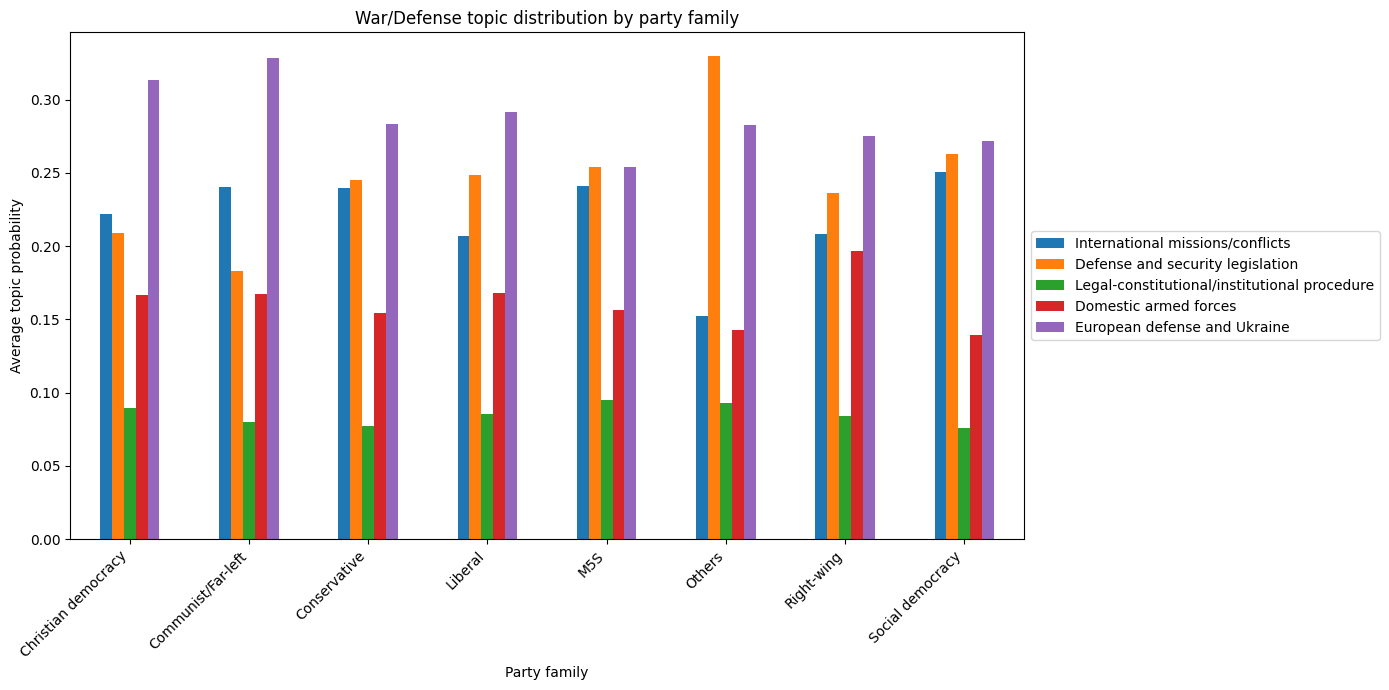

In [ ]:
import matplotlib.pyplot as plt

aggregate_by_party_war_labeled = (
    topic_by_party_family_war
    .rename(columns=topic_labels_war)
    .set_index("party_family")
)

fig, ax = plt.subplots(figsize=(14, 7))

aggregate_by_party_war_labeled.plot.bar(ax=ax)

plt.title("War/Defense topic distribution by party family")
plt.xlabel("Party family")
plt.ylabel("Average topic probability")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR_WAR / "topic_distribution_by_party_family_war.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# 10. Ideological groups

bloc_map = {
    "Communist/Far-left": "Left",
    "Social democracy": "Left",
    "Christian democracy": "Centre",
    "Liberal": "Centre",
    "Conservative": "Right",
    "Right-wing": "Right",
    "M5S": "Other / non-aligned",
    "Others": "Other / non-aligned"
}

topic_distros_war_docs["ideological_bloc"] = (
    topic_distros_war_docs["party_family"].map(bloc_map)
)

# Check mapping
topic_distros_war_docs[
    ["party_family", "ideological_bloc"]
].drop_duplicates().sort_values("party_family")

,party_family,ideological_bloc
18,Christian democracy,Centre
0,Communist/Far-left,Left
1,Conservative,Right
16,Liberal,Centre
4034,M5S,Other / non-aligned
4,Others,Other / non-aligned
2,Right-wing,Right
3,Social democracy,Left


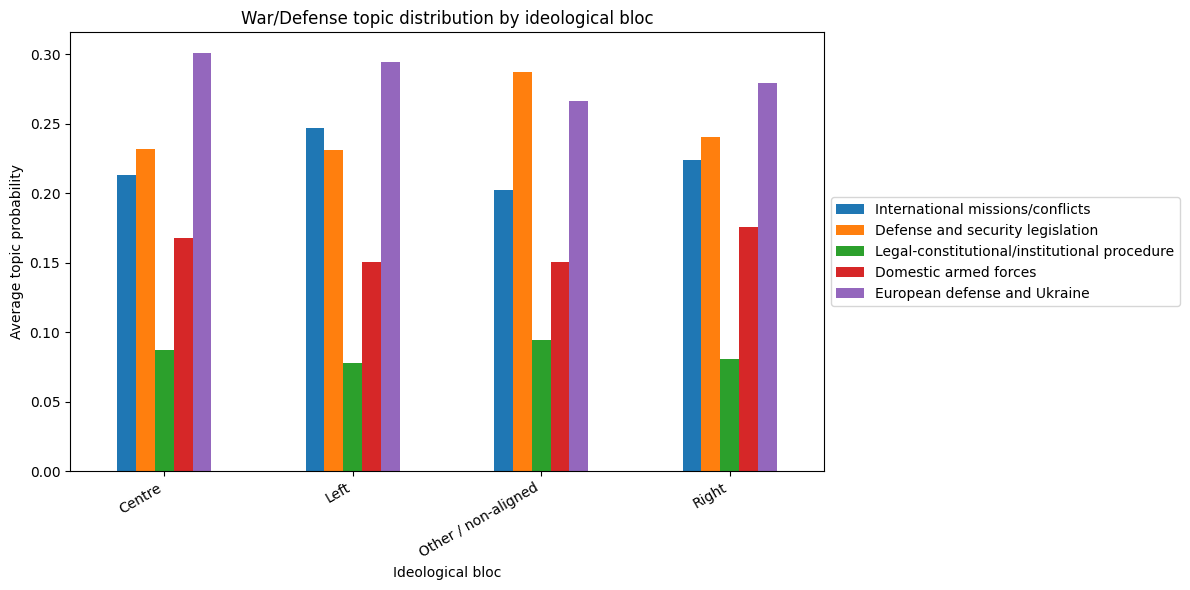

In [ ]:
# 11. Average topic distribution by ideological bloc
topic_by_bloc_war = (
    topic_distros_war_docs
    .groupby("ideological_bloc")[descriptors_war_docs]
    .mean()
)

# 12. Plot for ideological blocs
topic_by_bloc_war_labeled = topic_by_bloc_war.rename(columns=topic_labels_war)

fig, ax = plt.subplots(figsize=(12, 6))

topic_by_bloc_war_labeled.plot.bar(ax=ax)

plt.title("War/Defense topic distribution by ideological bloc")
plt.xlabel("Ideological bloc")
plt.ylabel("Average topic probability")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR_WAR / "topic_distribution_by_ideological_bloc_war.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# Create year periods for war-related parliamentary speeches

topic_distros_war_docs["year"] = pd.to_numeric(
    topic_distros_war_docs["year"],
    errors="coerce"
)

topic_distros_war_docs["year_period"] = pd.cut(
    topic_distros_war_docs["year"],
    bins=[2005, 2013, 2017, 2022],
    labels=["2006-2013", "2014-2017", "2018-2022"],
    include_lowest=True
)

topic_distros_war_docs[["year", "year_period"]].head()

,year,year_period
0,2006.0,2006-2013
1,2006.0,2006-2013
2,2006.0,2006-2013
3,2006.0,2006-2013
4,2006.0,2006-2013


/tmp/ipykernel_1087/3660500712.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("year_period")[descriptors_war_docs]


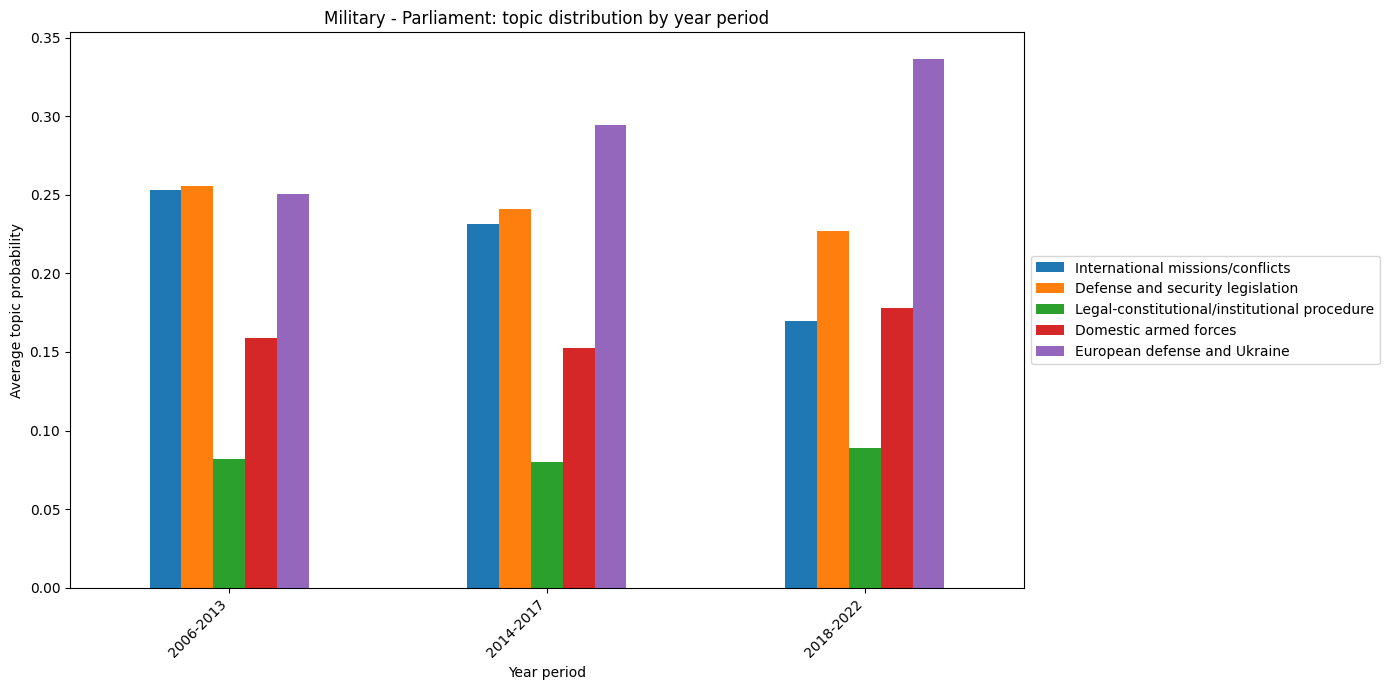

In [8]:
# Average topic distribution by year period
topic_by_year_war = (
    topic_distros_war_docs
    .groupby("year_period")[descriptors_war_docs]
    .mean()
)

# Plot for year periods
topic_by_year_war_labeled = topic_by_year_war.rename(columns=topic_labels_war)

fig, ax = plt.subplots(figsize=(14, 7))

topic_by_year_war_labeled.plot.bar(ax=ax)

plt.title("Military - Parliament: topic distribution by year period")
plt.xlabel("Year period")
plt.ylabel("Average topic probability")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR_WAR / "topic_distribution_by_year_period_war.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Manual validation of the model

In [ ]:
# Random sample 25 documents and insert them into a table with new empty column for human validation
manual_sample_war_25 = (
    topic_distros_war_docs
    .sample(n=25, random_state=42)
    .reset_index(drop=True)
)

annotation_blind_war_25 = manual_sample_war_25[
    ["speaker", "party_family", "year", "sentence"]
].copy()

annotation_blind_war_25.insert(0, "document_id", range(1, len(annotation_blind_war_25) + 1))

annotation_blind_war_25 = annotation_blind_war_25.rename(
    columns={"sentence": "document_text"}
)

annotation_blind_war_25["human_topic_label"] = ""

annotation_blind_war_25.head()

,document_id,speaker,party_family,year,document_text,human_topic_label
0,1,MASSIMO ARTINI,M5S,2015.0,"quindi, la domanda che mi pongo e perche, a di...",
1,2,MARISA NICCHI,Communist/Far-left,2014.0,pensiamo ad una misura che permetta la sperime...,
2,3,None,Others,2016.0,io ringrazio i deputati che hanno presentato q...,
3,4,GABRIELE BOSCETTO,Conservative,2006.0,"invece, tutto questo si e verificato in modo m...",
4,5,None,Others,2012.0,secondo tema e l'import dalla libia a seguito ...,


In [ ]:
# Save the table
annotation_blind_war_25.to_excel(
    ANNOTATION_DIR_UN / "lda_war_manual_validation.xlsx",
    index=False
)

print("Saved annotation file to:")
print(ANNOTATION_DIR_UN / "lda_war_manual_validation.xlsx")

Saved annotation file to:
/content/drive/MyDrive/nlp_project/annotation/lda_war_manual_validation.xlsx


The following cells are meant to create a table that compares manual human validation to the model's predicted topics

In [ ]:
manual_sample_war_25 = (
    topic_distros_war_docs
    .sample(n=25, random_state=42)
    .reset_index(drop=True)
)

manual_sample_war_25.insert(
    0,
    "document_id",
    range(1, len(manual_sample_war_25) + 1)
)

In [ ]:
war_topic_cols = [col for col in topic_distros_war_docs.columns if col.startswith("topic_")]

manual_sample_war_25["model_topic"] = (
    manual_sample_war_25[war_topic_cols]
    .idxmax(axis=1)
)

manual_sample_war_25["model_topic_label"] = (
    manual_sample_war_25["model_topic"]
    .str.replace("topic_", "", regex=False)
    .astype(int)
)

manual_sample_war_25["model_topic_prob"] = (
    manual_sample_war_25[war_topic_cols]
    .max(axis=1)
)

In [ ]:
ANNOTATION_DIR_UN = Path("/content/drive/MyDrive/nlp_project/annotation")
annotated_war = pd.read_excel(
    ANNOTATION_DIR_UN / "lda_war_manual_validation.xlsx"
)

annotated_war["human_topic_label"] = annotated_war["human_topic_label"].astype(int)

validation_war = annotated_war.merge(
    manual_sample_war_25[
        ["document_id", "model_topic", "model_topic_label", "model_topic_prob"] + war_topic_cols
    ],
    on="document_id",
    how="left"
)

validation_war["match"] = (
    validation_war["human_topic_label"] == validation_war["model_topic_label"]
)

validation_war[
    ["document_id", "human_topic_label", "model_topic_label", "model_topic_prob", "match"]
]

,document_id,human_topic_label,model_topic_label,model_topic_prob,match
0,1,0,0,0.525560,True
1,2,2,4,0.394208,False
2,3,2,1,0.514148,False
3,4,3,1,0.883396,False
4,5,0,4,0.602273,False
5,6,3,4,0.646464,False
6,7,3,3,0.709950,True
7,8,2,4,0.797032,False
8,9,0,0,0.526800,True
9,10,1,1,0.494191,True


In [ ]:
# Create clean checked validation file for war LDA

war_topic_cols = [col for col in topic_distros_war_docs.columns if col.startswith("topic_")]

# Keep only annotation columns needed for comparison
annotated_war_clean = annotated_war[
    ["document_id", "human_topic_label"]
].copy()

annotated_war_clean["human_topic_label"] = annotated_war_clean["human_topic_label"].astype(int)

# Merge with original sampled documents + model topic distributions
validation_war_clean = annotated_war_clean.merge(
    manual_sample_war_25[
        ["document_id", "speaker", "party_family", "year", "sentence"] + war_topic_cols
    ],
    on="document_id",
    how="left"
)

In [ ]:
# Topic probability matrix
topic_probs = validation_war_clean[war_topic_cols]

# Top 1, 2, 3 model topics
validation_war_clean["model_top1"] = topic_probs.idxmax(axis=1).str.replace("topic_", "").astype(int)
validation_war_clean["model_top1_prob"] = topic_probs.max(axis=1)

validation_war_clean["model_top2"] = topic_probs.apply(
    lambda row: row.sort_values(ascending=False).index[1].replace("topic_", ""),
    axis=1
).astype(int)

validation_war_clean["model_top2_prob"] = topic_probs.apply(
    lambda row: row.sort_values(ascending=False).iloc[1],
    axis=1
)

validation_war_clean["model_top3"] = topic_probs.apply(
    lambda row: row.sort_values(ascending=False).index[2].replace("topic_", ""),
    axis=1
).astype(int)

validation_war_clean["model_top3_prob"] = topic_probs.apply(
    lambda row: row.sort_values(ascending=False).iloc[2],
    axis=1
)

In [ ]:
# Match indicators
validation_war_clean["match_top1"] = (
    validation_war_clean["human_topic_label"] == validation_war_clean["model_top1"]
)

validation_war_clean["match_top2"] = validation_war_clean.apply(
    lambda row: row["human_topic_label"] in [row["model_top1"], row["model_top2"]],
    axis=1
)

validation_war_clean["match_top3"] = validation_war_clean.apply(
    lambda row: row["human_topic_label"] in [row["model_top1"], row["model_top2"], row["model_top3"]],
    axis=1
)

# Reorder columns cleanly
validation_war_clean = validation_war_clean[
    [
        "document_id",
        "speaker",
        "party_family",
        "year",
        "sentence",
        "human_topic_label",
        "model_top1",
        "model_top1_prob",
        "model_top2",
        "model_top2_prob",
        "model_top3",
        "model_top3_prob",
        "match_top1",
        "match_top2",
        "match_top3",
    ] + war_topic_cols
]

print("Top-1 match rate:", validation_war_clean["match_top1"].mean())
print("Top-2 match rate:", validation_war_clean["match_top2"].mean())
print("Top-3 match rate:", validation_war_clean["match_top3"].mean())

# Save one clean checked file
validation_war_clean.to_excel(
    ANNOTATION_DIR_UN / "CHECKED_lda_war_manual_validation.xlsx",
    index=False
)

print("Saved clean checked file to:")
print(ANNOTATION_DIR_UN / "CHECKED_lda_war_manual_validation.xlsx")

Top-1 match rate: 0.44
Top-2 match rate: 0.68
Top-3 match rate: 0.8
Saved clean checked file to:
/content/drive/MyDrive/nlp_project/annotation/CHECKED_lda_war_manual_validation.xlsx


### Saving

The following cells are used to save important outputs and model.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

OUTPUT_DIR_WAR = Path("/content/drive/MyDrive/nlp_project/lda_final_outputs_war")
OUTPUT_DIR_WAR.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", OUTPUT_DIR_WAR)

Saving outputs to: /content/drive/MyDrive/nlp_project/lda_final_outputs_war


In [ ]:
# Save final aggregated/preprocessed speech-level war dataset

df_docs_war.to_csv(
    OUTPUT_DIR_WAR / "df_docs_war_aggregated.csv",
    index=False
)

df_docs_war.to_pickle(
    OUTPUT_DIR_WAR / "df_docs_war_aggregated.pkl"
)

print("Saved df_docs_war")

Saved df_docs_war


In [ ]:
import pickle

# Save tokenized/bigram war documents used for LDA
with open(OUTPUT_DIR_WAR / "instances_bigram_war_docs.pkl", "wb") as f:
    pickle.dump(instances_bigram_docs, f)

print("Saved instances_bigram_war_docs")

Saved instances_bigram_war_docs


In [ ]:
# Save Gensim dictionary
dictionary_war_docs.save(str(OUTPUT_DIR_WAR / "dictionary_war_docs.gensim"))

# Save LDA corpus
with open(OUTPUT_DIR_WAR / "ldacorpus_war_docs.pkl", "wb") as f:
    pickle.dump(ldacorpus_war_docs, f)

print("Saved dictionary_war_docs and ldacorpus_war_docs")

Saved dictionary_war_docs and ldacorpus_war_docs


In [ ]:
# Save final war LDA model
final_model_war_docs.save(
    str(OUTPUT_DIR_WAR / "final_lda_model_war_docs_K5.model")
)

print(
    "Saved final model to:",
    OUTPUT_DIR_WAR / "final_lda_model_war_docs_K5.model"
)

Saved final model to: /content/drive/MyDrive/nlp_project/lda_final_outputs_war/final_lda_model_war_docs_K5.model


In [ ]:
# Save document-level topic distributions for war speeches

topic_distros_war_docs.to_csv(
    OUTPUT_DIR_WAR / "topic_distributions_war_docs.csv",
    index=False
)

topic_distros_war_docs.to_pickle(
    OUTPUT_DIR_WAR / "topic_distributions_war_docs.pkl"
)

print("Saved topic_distros_war_docs")

Saved topic_distros_war_docs


In [ ]:
# Save coherence results for war LDA models

coherence_df_war_docs.to_csv(
    OUTPUT_DIR_WAR / "coherence_results_war_docs.csv",
    index=False
)

with open(OUTPUT_DIR_WAR / "coherence_values_war_docs.pkl", "wb") as f:
    pickle.dump(coherence_values_war_docs, f)

print("Saved coherence results for war LDA models")

Saved coherence results for war LDA models


In [ ]:
# Final topic labels for war LDA model

topic_labels_war = {
    "topic_0": "International missions/conflicts",
    "topic_1": "Defense and security legislation",
    "topic_2": "Legal-constitutional/institutional procedure",
    "topic_3": "Domestic armed forces",
    "topic_4": "European defense and Ukraine"
}

pd.Series(topic_labels_war).to_csv(
    OUTPUT_DIR_WAR / "topic_labels_war.csv",
    header=["label"]
)

with open(OUTPUT_DIR_WAR / "topic_labels_war.pkl", "wb") as f:
    pickle.dump(topic_labels_war, f)

print("Saved war topic labels")

Saved war topic labels


In [ ]:
# Save aggregate topic-distribution tables for war LDA model

topic_by_party_family_war.to_csv(
    OUTPUT_DIR_WAR / "aggregate_topic_distribution_by_party_family_war.csv",
    index=False
)

print("Saved party-family aggregate table")

topic_by_year_war.to_csv(
    OUTPUT_DIR_WAR / "aggregate_topic_distribution_by_year_period_war.csv"
)

print("Saved year-period aggregate table")

topic_by_bloc_war.to_csv(
    OUTPUT_DIR_WAR / "aggregate_topic_distribution_by_ideological_bloc_war.csv"
)

print("Saved ideological-bloc aggregate table")

Saved party-family aggregate table
Saved year-period aggregate table
Saved ideological-bloc aggregate table


### Reloading

The following cell is used to reload the save outputs and model.

In [6]:
drive.mount("/content/drive")

OUTPUT_DIR_WAR = Path("/content/drive/MyDrive/nlp_project/lda_final_outputs_war")

# Reload aggregated/preprocessed speech-level dataset
df_docs_war = pd.read_pickle(
    OUTPUT_DIR_WAR / "df_docs_war_aggregated.pkl"
)

# Reload document-level topic distributions
topic_distros_war_docs = pd.read_pickle(
    OUTPUT_DIR_WAR / "topic_distributions_war_docs.pkl"
)

# Reload tokenized/bigram documents used for LDA
with open(OUTPUT_DIR_WAR / "instances_bigram_war_docs.pkl", "rb") as f:
    instances_bigram_docs = pickle.load(f)

# Reload Gensim dictionary
dictionary_war_docs = Dictionary.load(
    str(OUTPUT_DIR_WAR / "dictionary_war_docs.gensim")
)

# Reload LDA corpus
with open(OUTPUT_DIR_WAR / "ldacorpus_war_docs.pkl", "rb") as f:
    ldacorpus_war_docs = pickle.load(f)

# Reload final LDA model
final_model_war_docs = LdaModel.load(
    str(OUTPUT_DIR_WAR / "final_lda_model_war_docs_K5.model")
)

# Reload coherence results
coherence_df_war_docs = pd.read_csv(
    OUTPUT_DIR_WAR / "coherence_results_war_docs.csv"
)

# Reload topic labels
topic_labels_war = pd.read_csv(
    OUTPUT_DIR_WAR / "topic_labels_war.csv",
    index_col=0
)["label"].to_dict()

# Useful derived variables
num_topics_war_docs = len(topic_labels_war)
descriptors_war_docs = [f"topic_{i}" for i in range(num_topics_war_docs)]

print("Reloaded final war/defense LDA project outputs")

Mounted at /content/drive
Reloaded final war/defense LDA project outputs


## UN speeches

Similarly, we finish the analysis with topic modeling for UN speeches about war, using the same procedure as before.

In [ ]:
folder_url = "https://drive.google.com/drive/folders/1R9WW7IoX2YztQ435-1SxNdB5kViRnjR1"

# Download folder into a known directory
out_dir = "un_war_data"
gdown.download_folder(folder_url, output=out_dir, quiet=False, use_cookies=False)

# Check what was actually downloaded
for root, dirs, files in os.walk(out_dir):
    for f in files:
        print(os.path.join(root, f))

# Find pickle files
matches = glob.glob(f"{out_dir}/**/*.pkl", recursive=True)
print("Pickle files found:", matches)

# Then load the right one
pkl_path = [m for m in matches if "df_f1_w_un" in os.path.basename(m)]

if len(pkl_path) == 0:
    raise FileNotFoundError("df_f1_w_un.pkl was not found. Check the printed file names above.")

df_un_war = pd.read_pickle(pkl_path[0])
df_un_war.head()

Retrieving folder contents


Processing file 1boAconPCt423w_fDn4mN2sn95dned_Gg df_f1_w_un.pkl
Processing file 1jWG9U6rk5R_zHSQGlNeIQzOB2Y5Cl5R5 df_f1_w.pkl
Processing file 1piinosBgo-vff-Jg4O9j8WFhcie1CPFs df_f2_w.pkl
Processing file 1QDCqr7WtVIXvNaIh5ewrX0PlborEtGs- df_final_w_year.pkl
Processing file 1AaD8HrUOeUNzpnPbrIjX0VfnmXj8jEm_ df_final_w.pkl
Processing file 1WtuswqY1Ih2ovqM-6zA6FAaG6kowPmit df_semantic_w.pkl
Processing file 1AiHdeXZIhIcttEIiaVSwEA4sIcXO9nRL df_w_full.pkl
Processing file 1xfbYGwdIwquNVj_Hn6Jdxn-2FvCRmuzg df_w_L.pkl
Processing file 1zjabsuiEg4ym2S2mWtgMhf7N5w_0rndU df_w_presidente.pkl
Processing file 1cZMJPUXse4nP7xGnZyDgFKPHClQpaBe6 df_w_R.pkl
Processing file 147sL2c2zIdVIBPlvYrcRFdRs_A8yP4LG df_w_year_g.pkl
Processing file 1H2uNgpcfxcxLI8sp4vWjsks7xQU4Sb7w top_speeches_w.pkl


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1boAconPCt423w_fDn4mN2sn95dned_Gg
To: /content/un_war_data/df_f1_w_un.pkl
100%|██████████| 427k/427k [00:00<00:00, 119MB/s]
Downloading...
From: https://drive.google.com/uc?id=1jWG9U6rk5R_zHSQGlNeIQzOB2Y5Cl5R5
To: /content/un_war_data/df_f1_w.pkl
100%|██████████| 14.6M/14.6M [00:00<00:00, 61.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1piinosBgo-vff-Jg4O9j8WFhcie1CPFs
To: /content/un_war_data/df_f2_w.pkl
100%|██████████| 9.51M/9.51M [00:01<00:00, 5.11MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QDCqr7WtVIXvNaIh5ewrX0PlborEtGs-
To: /content/un_war_data/df_final_w_year.pkl
100%|██████████| 25.2M/25.2M [00:00<00:00, 72.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AaD8HrUOeUNzpnPbrIjX0VfnmXj8jEm_
To: /content/un_war_data/df_final_w.pkl
100%|██████████| 25.1M/25.1M [00:00<00:00, 142MB/s] 
Down

un_war_data/df_final_w.pkl
un_war_data/df_f1_w.pkl
un_war_data/df_semantic_w.pkl
un_war_data/df_w_year_g.pkl
un_war_data/df_w_presidente.pkl
un_war_data/top_speeches_w.pkl
un_war_data/df_f2_w.pkl
un_war_data/df_f1_w_un.pkl
un_war_data/df_final_w_year.pkl
un_war_data/df_w_L.pkl
un_war_data/df_w_R.pkl
un_war_data/df_w_full.pkl
Pickle files found: ['un_war_data/df_final_w.pkl', 'un_war_data/df_f1_w.pkl', 'un_war_data/df_semantic_w.pkl', 'un_war_data/df_w_year_g.pkl', 'un_war_data/df_w_presidente.pkl', 'un_war_data/top_speeches_w.pkl', 'un_war_data/df_f2_w.pkl', 'un_war_data/df_f1_w_un.pkl', 'un_war_data/df_final_w_year.pkl', 'un_war_data/df_w_L.pkl', 'un_war_data/df_w_R.pkl', 'un_war_data/df_w_full.pkl']


,row_id,DATE,TEXT,text_clean,sentence,sentence_id,keyword_hits,n_keyword_hits
0,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",they have rendered obsolete systems of collect...,9,"[defence, deterrence]",2
1,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",the recent experience in lebanon and the stren...,20,"[lebanon, unifil]",2
2,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...","in lebanon we are still at square one, and muc...",22,[lebanon],1
3,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...","for, while it is true that europe provides the...",26,[unifil],1
4,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",the question we must ask at this point is this...,27,[lebanon],1


In [ ]:
# 2. Preprocessing
nlp_en = spacy.load("en_core_web_sm")

custom_stopwords_un = {
    # UN / speech setting
    "united", "nations", "assembly",
    "president", "secretary", "general",
    "session", "meeting",
    "statement", "speech",

    # generic courtesy / procedural words
    "thank", "thanks",
    "today",
    "year",

    # war/conflict generic terms, optional
    # remove these only if they dominate the topics too much
    # "war", "conflict", "peace", "security"
}

def preprocess_english_text_un(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)

    doc = nlp_en(text)
    tokens = []

    for token in doc:
        lemma = token.lemma_.lower().strip()

        if token.is_stop:
            continue
        if token.is_punct or token.is_space:
            continue
        if token.like_num:
            continue
        if not token.is_alpha:
            continue
        if len(lemma) <= 2:
            continue
        if lemma in custom_stopwords_un:
            continue

        tokens.append(lemma)

    return tokens

# Apply preprocessing to the war dataframe
df_un_war["tokens"] = df_un_war["sentence"].apply(preprocess_english_text_un)

df_un_war["cleaned_text"] = df_un_war["tokens"].apply(lambda x: " ".join(x))

# Drop empty rows after preprocessing
df_un_war = df_un_war[df_un_war["tokens"].map(len) > 0].copy()

df_un_war.head()

,row_id,DATE,TEXT,text_clean,sentence,sentence_id,keyword_hits,n_keyword_hits,tokens,cleaned_text
0,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",they have rendered obsolete systems of collect...,9,"[defence, deterrence]",2,"[render, obsolete, system, collective, defence...",render obsolete system collective defence secu...
1,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",the recent experience in lebanon and the stren...,20,"[lebanon, unifil]",2,"[recent, experience, lebanon, strengthening, i...",recent experience lebanon strengthening interi...
2,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...","in lebanon we are still at square one, and muc...",22,[lebanon],1,"[lebanon, square, remain]",lebanon square remain
3,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...","for, while it is true that europe provides the...",26,[unifil],1,"[true, europe, provide, backbone, unifil, carr...",true europe provide backbone unifil carry miss...
4,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",the question we must ask at this point is this...,27,[lebanon],1,"[question, ask, point, need, order, continue, ...",question ask point need order continue work be...


In [ ]:
# 3. Add bigrams
from gensim.models.phrases import Phrases, Phraser

instances_un_war = df_un_war["tokens"].tolist()

bigram_un_war = Phrases(
    instances_un_war,
    min_count=2,
    threshold=8
)

bigram_mod_un_war = Phraser(bigram_un_war)

instances_bigram_un_war = [bigram_mod_un_war[doc] for doc in instances_un_war]

df_un_war["tokens_bigram"] = instances_bigram_un_war
df_un_war["cleaned_text_bigram"] = df_un_war["tokens_bigram"].apply(lambda x: " ".join(x))

In [ ]:
# 4. Create dictionary and corpus for UN war speeches
from gensim.corpora import Dictionary

dictionary_un_war = Dictionary(instances_bigram_un_war)

dictionary_un_war.filter_extremes(
    no_below=1,
    no_above=0.6
)

ldacorpus_un_war = [
    dictionary_un_war.doc2bow(text)
    for text in instances_bigram_un_war
]

print(dictionary_un_war)

Dictionary<876 unique tokens: ['base', 'collective', 'defence', 'deterrence', 'obsolete']...>


In [ ]:
# 5. Try K = 2, 3, 4, 5 and compare c_v coherence for UN war speeches

coherence_values_un_war = []
models_un_war = {}

for num_topics_un_war in [2, 3, 4, 5]:
    print(f"\nK = {num_topics_un_war}")

    temp_model_un_war = LdaMulticore(
        corpus=ldacorpus_un_war,
        id2word=dictionary_un_war,
        num_topics=num_topics_un_war,
        passes=20,          # a bit higher because corpus is small
        workers=2,
        random_state=42
    )

    coherence_model_un_war = CoherenceModel(
        model=temp_model_un_war,
        texts=instances_bigram_un_war,
        dictionary=dictionary_un_war,
        coherence="c_v"
    )

    cv_score_un_war = coherence_model_un_war.get_coherence()

    coherence_values_un_war.append((num_topics_un_war, cv_score_un_war))
    models_un_war[num_topics_un_war] = temp_model_un_war

    print("c_v:", cv_score_un_war)

    for topic_id, topic_words in temp_model_un_war.print_topics(
        num_topics=num_topics_un_war,
        num_words=12
    ):
        print(f"Topic {topic_id}: {topic_words}")

# Summary table
coherence_df_un_war = pd.DataFrame(
    coherence_values_un_war,
    columns=["K", "c_v"]
).sort_values("c_v", ascending=False)

coherence_df_un_war


K = 2
c_v: 0.4511194123343778
Topic 0: 0.013*"libya" + 0.012*"support" + 0.011*"country" + 0.009*"mission" + 0.009*"force" + 0.008*"italy" + 0.007*"military" + 0.007*"ukraine" + 0.006*"somalia" + 0.006*"security" + 0.006*"crisis" + 0.006*"humanitarian"
Topic 1: 0.013*"lebanon" + 0.011*"italy" + 0.007*"commitment" + 0.007*"ukraine" + 0.007*"country" + 0.007*"libya" + 0.006*"afghanistan" + 0.006*"international" + 0.006*"mediterranean" + 0.006*"africa" + 0.006*"security" + 0.006*"political"

K = 3
c_v: 0.4408618350144195
Topic 0: 0.012*"country" + 0.011*"force" + 0.011*"mission" + 0.010*"ukraine" + 0.008*"military" + 0.007*"humanitarian" + 0.007*"afghanistan" + 0.006*"libya" + 0.006*"support" + 0.006*"crisis" + 0.006*"deploy" + 0.005*"security"
Topic 1: 0.012*"lebanon" + 0.009*"ukraine" + 0.006*"crisis" + 0.006*"africa" + 0.006*"commitment" + 0.006*"people" + 0.006*"face" + 0.006*"country" + 0.005*"libya" + 0.005*"time" + 0.005*"contributor" + 0.005*"political"
Topic 2: 0.016*"italy" + 0

,K,c_v
2,4,0.456678
3,5,0.455422
0,2,0.451119
1,3,0.440862


In [ ]:
# 6. Train final model for UN war speeches

num_topics_un_war = 4  # chosen after inspecting coherence and interpretability

final_model_un_war = LdaModel(
    corpus=ldacorpus_un_war,
    id2word=dictionary_un_war,
    num_topics=num_topics_un_war,
    passes=20,
    random_state=42
)

for topic_id, topic_words in final_model_un_war.print_topics(
    num_topics=num_topics_un_war,
    num_words=15
):
    print(f"Topic {topic_id}: {topic_words}")

Topic 0: 0.014*"ukraine" + 0.009*"country" + 0.009*"italy" + 0.008*"libya" + 0.007*"security" + 0.007*"new" + 0.007*"military" + 0.007*"syria" + 0.007*"force" + 0.007*"support" + 0.007*"mission" + 0.005*"peace" + 0.005*"good" + 0.005*"crisis" + 0.005*"characterize"
Topic 1: 0.020*"lebanon" + 0.008*"africa" + 0.008*"ukraine" + 0.008*"country" + 0.007*"libya" + 0.007*"afghanistan" + 0.007*"middle_east" + 0.007*"mediterranean" + 0.007*"interim_force" + 0.006*"remain" + 0.006*"large_contributor" + 0.006*"contributor" + 0.006*"peacekeeping_operation" + 0.005*"people" + 0.005*"demonstrate"
Topic 2: 0.021*"italy" + 0.020*"libya" + 0.016*"support" + 0.012*"continue" + 0.010*"country" + 0.009*"commitment" + 0.009*"work" + 0.009*"lebanon" + 0.009*"situation" + 0.007*"contribute" + 0.007*"strong" + 0.007*"syria" + 0.007*"concern" + 0.007*"afghanistan" + 0.006*"role"
Topic 3: 0.012*"international" + 0.012*"force" + 0.009*"security" + 0.009*"mission" + 0.009*"country" + 0.008*"military" + 0.007*"co

In [ ]:
# 7. Topic Diversity for final UN war LDA model

# Number of top words considered per topic
num_words = 12

# Extract top words for each topic
topic_words_un_war = [
    [word for word, prob in final_model_un_war.show_topic(topic_id, topn=num_words)]
    for topic_id in range(num_topics_un_war)
]

# Collect unique words across all topics
unique_words_un_war = set()

for topic in topic_words_un_war:
    unique_words_un_war.update(topic[:num_words])

# Topic Diversity:
# ratio of unique words to total number of words across all topics
td_un_war = len(unique_words_un_war) / (num_words * len(topic_words_un_war))

print(
    f"Topic Diversity (top-{num_words} words): {td_un_war:.4f} "
    f"[unique words = {len(unique_words_un_war)}, "
    f"total words = {num_words * len(topic_words_un_war)}]"
)

Topic Diversity (top-12 words): 0.6667 [unique words = 32, total words = 48]


In [ ]:
# 8. Get topic distribution for each UN war speech/document and attach metadata

topic_corpus_un_war = final_model_un_war.get_document_topics(
    ldacorpus_un_war,
    minimum_probability=0
)

descriptors_un_war = [f"topic_{i}" for i in range(num_topics_un_war)]

scores_un_war = [
    [topic_prob for topic_id, topic_prob in doc_topics]
    for doc_topics in topic_corpus_un_war
]

topic_distros_un_war = pd.DataFrame(
    data=scores_un_war,
    columns=descriptors_un_war
)

# Attach metadata columns only if they exist
metadata_cols = ["country", "year", "date", "speaker", "sentence"]

for col in metadata_cols:
    if col in df_un_war.columns:
        topic_distros_un_war[col] = df_un_war[col].values

topic_distros_un_war.head()

,topic_0,topic_1,topic_2,topic_3,sentence
0,0.914481,0.028712,0.028011,0.028796,they have rendered obsolete systems of collect...
1,0.016795,0.949293,0.016906,0.017007,the recent experience in lebanon and the stren...
2,0.305592,0.567418,0.063970,0.063020,"in lebanon we are still at square one, and muc..."
3,0.012949,0.012726,0.012778,0.961548,"for, while it is true that europe provides the..."
4,0.025258,0.026013,0.923269,0.025459,the question we must ask at this point is this...


In [ ]:
# 10. Group by year period

topic_distros_un_war["DATE"] = df_un_war["DATE"].values

# DATE is actually a year, not a full date
topic_distros_un_war["year"] = pd.to_numeric(
    topic_distros_un_war["DATE"],
    errors="coerce"
).astype("Int64")

topic_distros_un_war["year_period"] = pd.cut(
    topic_distros_un_war["year"],
    bins=[2005, 2013, 2017, 2022],
    labels=["2006-2013", "2014-2017", "2018-2022"],
    include_lowest=True
)

topic_distros_un_war[["DATE", "year", "year_period"]].head()

,DATE,year,year_period
0,2006,2006,2006-2013
1,2006,2006,2006-2013
2,2006,2006,2006-2013
3,2006,2006,2006-2013
4,2006,2006,2006-2013


In [ ]:
# Topic labels
topic_labels_un_war = {
    "topic_0": "Ukraine and Libya crises ",
    "topic_1": "Lebanon, Africa, Middle East crises",
    "topic_2": "Italy's commitment",
    "topic_3": "International security and military missions"
}

In [ ]:
# Needed to save plot
OUTPUT_DIR_UN_WAR = Path("/content/drive/MyDrive/nlp_project/lda_final_outputs_un_war")
OUTPUT_DIR_UN_WAR.mkdir(parents=True, exist_ok=True)

/tmp/ipykernel_4680/1359765308.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("year_period")[descriptors_un_war]


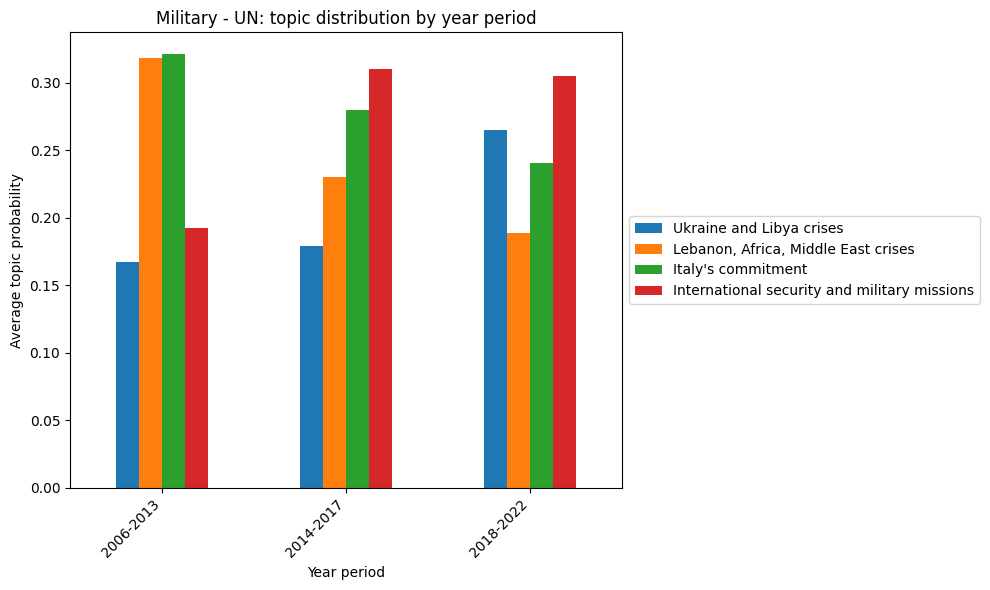

Saved UN war year-period plot


In [ ]:
import matplotlib.pyplot as plt

aggregate_by_year_period_un_war = (
    topic_distros_un_war
    .dropna(subset=["year_period"])
    .groupby("year_period")[descriptors_un_war]
    .mean()
    .rename(columns=topic_labels_un_war)
)

fig, ax = plt.subplots(figsize=(10, 6))

aggregate_by_year_period_un_war.plot.bar(ax=ax)

plt.title("Military - UN: topic distribution by year period")
plt.xlabel("Year period")
plt.ylabel("Average topic probability")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR_UN_WAR / "topic_distribution_by_year_period_un_war.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved UN war year-period plot")

### Manual validation of the model

In [ ]:
from pathlib import Path

ANNOTATION_DIR_UN = Path("/content/drive/MyDrive/nlp_project/annotation")
ANNOTATION_DIR_UN.mkdir(parents=True, exist_ok=True)

print("Saving annotation files to:", ANNOTATION_DIR_UN)

Saving annotation files to: /content/drive/MyDrive/nlp_project/annotation


In [ ]:
# Randomly sample 25 UN war sentences/documents for manual validation

manual_sample_25_un_war = (
    topic_distros_un_war
    .sample(n=25, random_state=42)
    .reset_index(drop=True)
)

# Select available metadata columns
candidate_cols_un_war = ["country", "speaker", "year", "year_period", "sentence"]
available_cols_un_war = [
    col for col in candidate_cols_un_war
    if col in manual_sample_25_un_war.columns
]

annotation_blind_25_un_war = manual_sample_25_un_war[
    available_cols_un_war
].copy()

# Add document ID
annotation_blind_25_un_war.insert(
    0,
    "document_id",
    range(1, len(annotation_blind_25_un_war) + 1)
)

# Rename sentence column for annotation
annotation_blind_25_un_war = annotation_blind_25_un_war.rename(
    columns={"sentence": "document_text"}
)

# Add empty human annotation column
annotation_blind_25_un_war["human_topic_label"] = ""

annotation_blind_25_un_war.head()

,document_id,year,year_period,document_text,human_topic_label
0,1,2018,2018-2022,in the upcoming weeks italy will host a confer...,
1,2,2015,2014-2017,this open debate of the general assembly has b...,
2,3,2016,2014-2017,"in comparison, while we can say that progress ...",
3,4,2015,2014-2017,"i think, therefore, that it is important that ...",
4,5,2020,2018-2022,"just over two weeks ago, i visited lebanon, to...",


In [ ]:
annotation_blind_25_un_war.to_excel(
    ANNOTATION_DIR_UN / "lda_un_war_manual_validation.xlsx",
    index=False
)

print("Saved UN war annotation file to:")
print(ANNOTATION_DIR_UN / "lda_un_war_manual_validation.xlsx")

Saved UN war annotation file to:
/content/drive/MyDrive/nlp_project/annotation/lda_un_war_manual_validation.xlsx


The following cells are meant to create a table that compares manual human validation to the model's predicted topics

In [ ]:
# 1. Load annotated file
annotated_un_war = pd.read_excel(
    ANNOTATION_DIR_UN / "ANNOTATED_lda_un_war_manual_validation.xlsx"
)

annotated_un_war = annotated_un_war[["document_id", "human_topic_label"]].copy()
annotated_un_war["human_topic_label"] = annotated_un_war["human_topic_label"].astype(int)

# 2. Recreate the same 25 sampled documents
manual_sample_25_un_war = (
    topic_distros_un_war
    .sample(n=25, random_state=42)
    .reset_index(drop=True)
)

manual_sample_25_un_war.insert(
    0,
    "document_id",
    range(1, len(manual_sample_25_un_war) + 1)
)

In [ ]:
# 3. Identify topic probability columns
un_war_topic_cols = [
    col for col in topic_distros_un_war.columns
    if col.startswith("topic_")
]

# 4. Select metadata columns
metadata_cols_un_war = [
    col for col in ["country", "speaker", "year", "year_period", "sentence"]
    if col in manual_sample_25_un_war.columns
]

# 5. Merge annotations with sampled documents and topic probabilities
validation_un_war_clean = annotated_un_war.merge(
    manual_sample_25_un_war[
        ["document_id"] + metadata_cols_un_war + un_war_topic_cols
    ],
    on="document_id",
    how="left"
)

In [ ]:
# 6. Compute top 1, top 2, top 3 model topics
topic_probs_un_war = validation_un_war_clean[un_war_topic_cols]

validation_un_war_clean["model_top1"] = (
    topic_probs_un_war.idxmax(axis=1)
    .str.replace("topic_", "", regex=False)
    .astype(int)
)
validation_un_war_clean["model_top1_prob"] = topic_probs_un_war.max(axis=1)

validation_un_war_clean["model_top2"] = topic_probs_un_war.apply(
    lambda row: row.sort_values(ascending=False).index[1].replace("topic_", ""),
    axis=1
).astype(int)

validation_un_war_clean["model_top2_prob"] = topic_probs_un_war.apply(
    lambda row: row.sort_values(ascending=False).iloc[1],
    axis=1
)

validation_un_war_clean["model_top3"] = topic_probs_un_war.apply(
    lambda row: row.sort_values(ascending=False).index[2].replace("topic_", ""),
    axis=1
).astype(int)

validation_un_war_clean["model_top3_prob"] = topic_probs_un_war.apply(
    lambda row: row.sort_values(ascending=False).iloc[2],
    axis=1
)

In [ ]:
# 7. Match indicators
validation_un_war_clean["match_top1"] = (
    validation_un_war_clean["human_topic_label"]
    == validation_un_war_clean["model_top1"]
)

validation_un_war_clean["match_top2"] = validation_un_war_clean.apply(
    lambda row: row["human_topic_label"] in [row["model_top1"], row["model_top2"]],
    axis=1
)

validation_un_war_clean["match_top3"] = validation_un_war_clean.apply(
    lambda row: row["human_topic_label"] in [
        row["model_top1"],
        row["model_top2"],
        row["model_top3"]
    ],
    axis=1
)

# 8. Reorder columns
validation_un_war_clean = validation_un_war_clean[
    ["document_id"]
    + metadata_cols_un_war
    + [
        "human_topic_label",
        "model_top1",
        "model_top1_prob",
        "model_top2",
        "model_top2_prob",
        "model_top3",
        "model_top3_prob",
        "match_top1",
        "match_top2",
        "match_top3",
    ]
    + un_war_topic_cols
]

# 9. Save clean checked file
validation_un_war_clean.to_excel(
    ANNOTATION_DIR_UN / "CHECKED_lda_un_war_manual_validation.xlsx",
    index=False
)

print("Top-1 match rate:", validation_un_war_clean["match_top1"].mean())
print("Top-2 match rate:", validation_un_war_clean["match_top2"].mean())
print("Top-3 match rate:", validation_un_war_clean["match_top3"].mean())

print("Saved checked file to:")
print(ANNOTATION_DIR_UN / "CHECKED_lda_un_war_manual_validation.xlsx")

Top-1 match rate: 0.08
Top-2 match rate: 0.56
Top-3 match rate: 0.84
Saved checked file to:
/content/drive/MyDrive/nlp_project/annotation/CHECKED_lda_un_war_manual_validation.xlsx


### Saving

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

OUTPUT_DIR_UN_WAR = Path("/content/drive/MyDrive/nlp_project/lda_final_outputs_un_war")
OUTPUT_DIR_UN_WAR.mkdir(parents=True, exist_ok=True)

print("Saving UN war outputs to:", OUTPUT_DIR_UN_WAR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving UN war outputs to: /content/drive/MyDrive/nlp_project/lda_final_outputs_un_war


In [ ]:
df_un_war.to_csv(
    OUTPUT_DIR_UN_WAR / "df_un_war_processed.csv",
    index=False
)

df_un_war.to_pickle(
    OUTPUT_DIR_UN_WAR / "df_un_war_processed.pkl"
)

print("Saved df_un_war")

Saved df_un_war


In [ ]:
import pickle

with open(OUTPUT_DIR_UN_WAR / "instances_bigram_un_war.pkl", "wb") as f:
    pickle.dump(instances_bigram_un_war, f)

print("Saved instances_bigram_un_war")

Saved instances_bigram_un_war


In [ ]:
dictionary_un_war.save(
    str(OUTPUT_DIR_UN_WAR / "dictionary_un_war.gensim")
)

with open(OUTPUT_DIR_UN_WAR / "ldacorpus_un_war.pkl", "wb") as f:
    pickle.dump(ldacorpus_un_war, f)

print("Saved dictionary_un_war and ldacorpus_un_war")

Saved dictionary_un_war and ldacorpus_un_war


In [ ]:
final_model_un_war.save(
    str(OUTPUT_DIR_UN_WAR / "final_lda_model_un_war_K4.model")
)

print("Saved final UN war model to:", OUTPUT_DIR_UN_WAR / "final_lda_model_un_war_K4.model")

Saved final UN war model to: /content/drive/MyDrive/nlp_project/lda_final_outputs_un_war/final_lda_model_un_war_K4.model


In [ ]:
topic_distros_un_war.to_csv(
    OUTPUT_DIR_UN_WAR / "topic_distributions_un_war.csv",
    index=False
)

topic_distros_un_war.to_pickle(
    OUTPUT_DIR_UN_WAR / "topic_distributions_un_war.pkl"
)

print("Saved topic_distros_un_war")

Saved topic_distros_un_war


In [ ]:
# Save topic words
with open(OUTPUT_DIR_UN_WAR / "topic_words_un_war.pkl", "wb") as f:
    pickle.dump(topic_words_un_war, f)

# Save topic diversity as CSV
topic_diversity_un_war_df = pd.DataFrame({
    "num_words": [num_words],
    "num_topics": [num_topics_un_war],
    "topic_diversity": [td_un_war],
    "unique_words": [len(unique_words_un_war)],
    "total_words": [num_words * len(topic_words_un_war)]
})

topic_diversity_un_war_df.to_csv(
    OUTPUT_DIR_UN_WAR / "topic_diversity_un_war.csv",
    index=False
)

# Save topic diversity as pickle
with open(OUTPUT_DIR_UN_WAR / "topic_diversity_un_war.pkl", "wb") as f:
    pickle.dump(td_un_war, f)

print("Saved topic words and topic diversity")

Saved topic words and topic diversity


In [ ]:
topic_labels_un_war = {
    "topic_0": "Ukraine and Libya crises ",
    "topic_1": "Lebanon, Africa, Middle East crises",
    "topic_2": "Italy's commitment",
    "topic_3": "International security and military missions"
}

pd.Series(topic_labels_un_war).to_csv(
    OUTPUT_DIR_UN_WAR / "topic_labels_un_war.csv",
    header=["label"]
)

with open(OUTPUT_DIR_UN_WAR / "topic_labels_un_war.pkl", "wb") as f:
    pickle.dump(topic_labels_un_war, f)

print("Saved UN war topic labels")

Saved UN war topic labels


In [ ]:
aggregate_by_year_period_un_war.to_csv(
    OUTPUT_DIR_UN_WAR / "aggregate_topic_distribution_by_year_period_un_war.csv"
)

aggregate_by_year_period_un_war.to_pickle(
    OUTPUT_DIR_UN_WAR / "aggregate_topic_distribution_by_year_period_un_war.pkl"
)

print("Saved UN war year-period aggregate table")

Saved UN war year-period aggregate table


In [ ]:
un_war_config = {
    "num_topics_un_war": num_topics_un_war,
    "num_words": num_words,
    "descriptors_un_war": descriptors_un_war,
    "year_period_bins": [2005, 2013, 2017, 2022],
    "year_period_labels": ["2006-2013", "2014-2017", "2018-2022"]
}

with open(OUTPUT_DIR_UN_WAR / "un_war_config.pkl", "wb") as f:
    pickle.dump(un_war_config, f)

print("Saved UN war config")

Saved UN war config


In [ ]:
saved_files_un_war = sorted([p.name for p in OUTPUT_DIR_UN_WAR.iterdir()])

print("Saved UN war files:")
for file in saved_files_un_war:
    print("-", file)

Saved UN war files:
- aggregate_topic_distribution_by_year_period_un_war.csv
- aggregate_topic_distribution_by_year_period_un_war.pkl
- df_un_migration_processed.csv
- df_un_migration_processed.pkl
- df_un_war_processed.csv
- df_un_war_processed.pkl
- dictionary_un_war.gensim
- final_lda_model_un_war_K4.model
- final_lda_model_un_war_K4.model.expElogbeta.npy
- final_lda_model_un_war_K4.model.id2word
- final_lda_model_un_war_K4.model.state
- instances_bigram_un_war.pkl
- ldacorpus_un_war.pkl
- topic_distribution_by_year_period_un_war.png
- topic_distributions_un_war.csv
- topic_distributions_un_war.pkl
- topic_diversity_un_war.csv
- topic_diversity_un_war.pkl
- topic_labels_un_war.csv
- topic_labels_un_war.pkl
- topic_words_un_war.pkl
- un_war_config.pkl


### Reloading

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

matches = list(Path("/content/drive").rglob("df_un_war_processed.pkl"))

print("Matches found:")
for m in matches:
    print(m)

OUTPUT_DIR_UN_WAR = matches[0].parent
print("Using OUTPUT_DIR_UN_WAR:", OUTPUT_DIR_UN_WAR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Matches found:
/content/drive/MyDrive/nlp_project/lda_final_outputs_un_war/df_un_war_processed.pkl
Using OUTPUT_DIR_UN_WAR: /content/drive/MyDrive/nlp_project/lda_final_outputs_un_war


In [ ]:
import pickle
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaModel

df_un_war = pd.read_pickle(
    OUTPUT_DIR_UN_WAR / "df_un_war_processed.pkl"
)

topic_distros_un_war = pd.read_pickle(
    OUTPUT_DIR_UN_WAR / "topic_distributions_un_war.pkl"
)

with open(OUTPUT_DIR_UN_WAR / "instances_bigram_un_war.pkl", "rb") as f:
    instances_bigram_un_war = pickle.load(f)

dictionary_un_war = Dictionary.load(
    str(OUTPUT_DIR_UN_WAR / "dictionary_un_war.gensim")
)

with open(OUTPUT_DIR_UN_WAR / "ldacorpus_un_war.pkl", "rb") as f:
    ldacorpus_un_war = pickle.load(f)

final_model_un_war = LdaModel.load(
    str(OUTPUT_DIR_UN_WAR / "final_lda_model_un_war_K4.model")
)

with open(OUTPUT_DIR_UN_WAR / "topic_words_un_war.pkl", "rb") as f:
    topic_words_un_war = pickle.load(f)

with open(OUTPUT_DIR_UN_WAR / "topic_diversity_un_war.pkl", "rb") as f:
    td_un_war = pickle.load(f)

topic_labels_un_war = pd.read_csv(
    OUTPUT_DIR_UN_WAR / "topic_labels_un_war.csv",
    index_col=0
)["label"].to_dict()

aggregate_by_year_period_un_war = pd.read_pickle(
    OUTPUT_DIR_UN_WAR / "aggregate_topic_distribution_by_year_period_un_war.pkl"
)

with open(OUTPUT_DIR_UN_WAR / "un_war_config.pkl", "rb") as f:
    un_war_config = pickle.load(f)

num_topics_un_war = un_war_config["num_topics_un_war"]
num_words = un_war_config["num_words"]
descriptors_un_war = un_war_config["descriptors_un_war"]

print("Reloaded final UN war LDA project outputs")
print(dictionary_un_war)
print(f"Topic diversity: {td_un_war:.4f}")

Reloaded final UN war LDA project outputs
Dictionary<876 unique tokens: ['base', 'collective', 'defence', 'deterrence', 'obsolete']...>
Topic diversity: 0.6667
